##### Master Degree in Computer Science and Data Science for Economics and Health

# From vectors to classification: neural networks, probabilities and evaluation

### Prof. Alfio Ferrara

## Introduction

In the previous notebook a text became a **vector** in a space whose dimensions are terms, and we used the geometry of that space to compare a document with a query. The vector was the end of the story: the search engine returned the documents that were closest to the query.

Now we use the same vector as the **input of a model** that has to answer a question about the text. Given the ingredients of a recipe, *which cuisine does it belong to?* Is it a Thai or a Mexican recipe? This is a **classification** problem, and neural networks are one of the ways to solve it.

We are going to look at classification in a slightly unusual way. A classifier is usually described as a function that returns a label. We will describe it as a function that returns a **probability distribution over the classes**: for a recipe, how likely is each cuisine? The label that we are used to is only a by-product, the class to which the model gives the highest probability. This point of view has two consequences. It gives us a way to measure how good a model is that does not reduce to counting right and wrong answers (the **perplexity**), and it is exactly the point of view of the language models that we will meet later in the course, where the classes are the words of the vocabulary and the task is to predict the next one.

In this notebook we will:

1. prepare the data: the labels, the split, and the TF-IDF vectors of the ingredients;
2. build a network **without hidden layers** from scratch, first for a binary problem and then for many classes;
3. add a **hidden layer** using PyTorch, and look at what it does to the representation of the text;
4. measure the quality of the models, with precision, recall, F1 and perplexity, and compare them.

## The data

### Recipes and ingredients

We use the same collection of recipes of the previous notebook. As the text of each recipe we take **only the list of the ingredients**, and not the title or the instructions. There are practical reasons (the vocabulary is much smaller, and the model is faster to train and easier to read), and there is a methodological one: the title often names the dish (`Cuban Black Beans and Rice`), and a model that reads it does not need to *learn* anything about the cuisine.

We normalize the ingredients as we did in the previous notebook: lemmas, lowercase, no stop words, no punctuation.

In [1]:
import html
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from nlp.utils import show

with open("/Users/Flint/Data/recipes/foodcom/subsets/recipes_cuisine_tipo_10k.json") as f:
    recipes = json.load(f)

def document(recipe):
    return ", ".join(recipe["ingredients"])

documents = [document(r) for r in recipes]
print(f"{len(documents)} recipes")
show(documents[0], width=90)

9951 recipes
black beans, water, green pepper, onion, garlic cloves, green pepper, olive oil, salt,
black pepper, oregano, bay leaf, sugar, vinegar, white wine, olive oil, olive oil, garlic
cloves, water, salt, rice


In [2]:
import spacy

from nlp.preprocessing import TextNormalizer

nlp = spacy.load("en_core_web_lg", disable=["parser", "ner"])
normalizer = TextNormalizer(lemmatize=True, remove_stopwords=True)
terms = [normalizer(doc) for doc in nlp.pipe(documents, batch_size=200)]

show(terms[0], width=90)

['black', 'bean', 'water', 'green', 'pepper', 'onion', 'garlic', 'clove', 'green',
 'pepper', 'olive', 'oil', 'salt', 'black', 'pepper', 'oregano', 'bay', 'leaf', 'sugar',
 'vinegar', 'white', 'wine', 'olive', 'oil', 'olive', 'oil', 'garlic', 'clove', 'water',
 'salt', 'rice']


### Which labels?

Each recipe has two fields that we can use as a label: the **cuisine** (`Thai`, `Mexican`, ...) and the **type** of dish (`Dessert`, `Soup/Stew`, ...). Both are missing for a part of the recipes, and we need to drop them: a recipe without a label cannot be used to train a model or to measure its quality.

The two labelings define two different classification problems. In the notebook the choice of the problem is made by a single object, a `LabelScheme`, so that we can change it and repeat all the experiments. It also builds a **binary** version of a problem (one class against all the others) and can make the classes **unbalanced**, and we will use both.

In [3]:
from nlp.classification import LabelScheme

schemes = {"cuisine": LabelScheme("cuisine"), "type": LabelScheme("type")}

rows = {}
for name, scheme in schemes.items():
    indices, labels, classes = scheme.apply(recipes)
    counts = np.bincount(labels)
    rows[name] = {"recipes with a label": len(indices), "classes": len(classes),
                  "smallest class": counts.min(), "largest class": counts.max(),
                  "largest class, share": counts.max() / counts.sum()}

pd.DataFrame(rows).T.style.format({"largest class, share": "{:.1%}"})

,recipes with a label,classes,smallest class,largest class,"largest class, share"
cuisine,5349.000000,10.000000,508.000000,612.000000,11.4%
type,7060.000000,8.000000,745.000000,1084.000000,15.4%


Both problems are **almost balanced**: the smallest and the largest class of the cuisine have 508 and 612 recipes, and a model that always answers with the largest class (`Mexican`) is right 11.4% of the times. Only 5,349 recipes out of 9,951 (54%) have a cuisine, so from now on we work on these ones. It is a small dataset for a neural network, and this is going to be useful to see what happens when a model has more parameters than examples.

We use the **cuisine** as the main problem, and the type of dish later on, to see how a different problem changes the way in which the models behave.

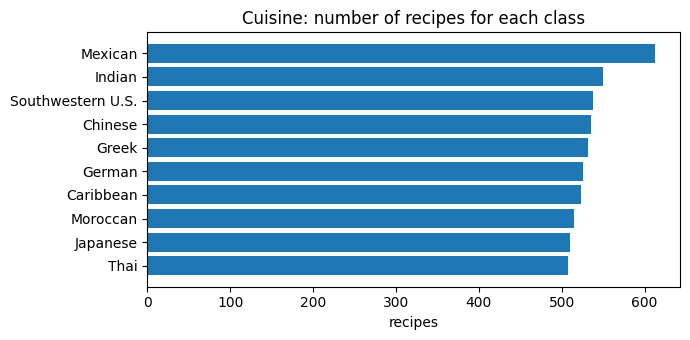

In [4]:
indices, labels, classes = schemes["cuisine"].apply(recipes)

counts = pd.Series(np.bincount(labels), index=classes).sort_values()
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.barh(counts.index, counts.values)
ax.set_xlabel("recipes")
ax.set_title("Cuisine: number of recipes for each class")
plt.tight_layout()

### A binary problem

The cuisine is a problem with ten classes. To start with something simpler, we build a **binary** problem: is this recipe Thai or not? The classes are now `Thai` (positive class) and `not Thai`, and the class of the non-Thai recipes collects the other nine cuisines.

In [5]:
binary = LabelScheme("cuisine", positive="Thai")
b_indices, b_labels, b_classes = binary.apply(recipes)

pd.DataFrame({"recipes": np.bincount(b_labels), "share": np.bincount(b_labels) / len(b_labels)},
             index=b_classes).style.format({"share": "{:.1%}"})

,recipes,share
not Thai,4841,90.5%
Thai,508,9.5%


### Train, validation and test

We split the recipes in three sets. The model **learns** on the training set. The **validation** set is used while we develop the model (to choose its parameters and to decide when to stop the training), and the **test** set is used only once, at the end, to measure the quality of what we built. A model that is evaluated on the recipes on which it learned tells us how well it memorized them, and not how well it works on a recipe that it has never seen.

The three sets keep the proportion of the classes (`stratify`), which is important when a class is rare.

In [6]:
from nlp.classification import split

train, validation, test = split(labels)

pd.DataFrame({name: {"recipes": len(s), "Thai": (labels[s] == list(classes).index("Thai")).mean()}
              for name, s in {"train": train, "validation": validation, "test": test}.items()}
             ).T.style.format({"Thai": "{:.1%}"})

,recipes,Thai
train,3209.000000,9.5%
validation,1070.000000,9.5%
test,1070.000000,9.4%


### TF-IDF vectors

The vocabulary and the IDF are computed **on the training set only**. If we computed them on all the recipes, the validation and test sets would influence the representation of the training set: a small leak of information from the sets that we should not have seen. The other sets are only *transformed* with the vocabulary and the IDF of the training set, and the terms that are not in the vocabulary are ignored.

We use the `TfidfVectorizer` of scikit-learn. It is a variant of the weighting of the previous notebook: the IDF is smoothed, the TF is the raw count of the term, and every vector is normalized to unit length (which is convenient for training a model). We also drop the terms that occur in a single recipe of the training set, that are useless for a model that has to generalize.

In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(analyzer=lambda t: t, min_df=2)
X_train = vectorizer.fit_transform([terms[indices[i]] for i in train])
X_validation = vectorizer.transform([terms[indices[i]] for i in validation])
X_test = vectorizer.transform([terms[indices[i]] for i in test])
vocabulary = vectorizer.get_feature_names_out()

print(f"Training matrix: {X_train.shape[0]} recipes x {X_train.shape[1]} terms")
print(f"Non-zero values for each recipe: {X_train.getnnz(axis=1).mean():.1f} on average")
print(f"Density of the matrix: {X_train.nnz / np.prod(X_train.shape):.2%}")

Training matrix: 3209 recipes x 768 terms
Non-zero values for each recipe: 14.7 on average
Density of the matrix: 1.91%


The matrix is very **sparse**: the vocabulary has 768 terms, but a recipe has only 14.7 of them on average (a density of 1.9%). Each recipe is a vector with 768 dimensions in which almost all the coordinates are zero. This is the representation that we give as input to the models.

As an example, these are the weights of a Thai recipe. A high weight means that the term is *characteristic of this recipe compared with the others*, and not that it is characteristic of the Thai cuisine: the connection between the terms and the class is not in the vector, it is what the model has to learn from the labels.

Notice also `spring` and `green`, among the top terms. They come from ingredients such as *spring onions* and *green curry paste*, that our tokenization has split into single words: as in the first notebooks, the choice of the token decides what the model can see, and here the unit that means something (the ingredient) is not the unit that we count.

In [8]:
def top_terms(x, n=8):
    row = x.toarray().ravel()
    order = np.argsort(-row, kind="stable")[:n]
    return pd.DataFrame({"term": vocabulary[order], "weight": row[order]})

example = next(i for i, p in enumerate(train) if recipes[indices[p]]["title"] == "Green Curried Fish")
show(recipes[indices[train[example]]]["title"])
top_terms(X_train[example]).style.format({"weight": "{:.2f}"}).hide(axis="index")

Green Curried Fish


term,weight
spring,0.34
green,0.32
fresh,0.28
basil,0.27
fish,0.26
curry,0.24
coconut,0.24
paste,0.24


### What we want from a model

We have a matrix $X$ with a row for each recipe, and a label for each row. In the usual description of classification, a model is a function $f$ such that $f(x)$ is a class. We describe it differently: the model is a function that, given the vector $x$ of a recipe, returns a **probability distribution over the classes**

$$P(c \mid x) \qquad c \in \{\text{Caribbean}, \text{Chinese}, \dots, \text{Thai}\}, \qquad \sum_c P(c \mid x) = 1$$

The label of the training set is a very special distribution, that gives probability 1 to one class and 0 to all the others (a *one-hot* vector). **Learning** means finding a model whose distribution is close to the distributions of the training set, and **predicting** a class means, in the end, choosing one class in the distribution that the model returns. The simplest way of doing it is to take the class with the highest probability, but it is not the only one, as we will see.

## A network without hidden layers

### A single neuron

The simplest neural network has an input layer, made of the 768 terms, and a single output unit, the **neuron**. The neuron does two things:

1. it computes a **weighted sum** of its inputs, $z = \sum_j w_j x_j + b$, where $x_j$ is the TF-IDF weight of the term $j$ in the recipe, $w_j$ is a **weight** that the model has to learn (one for each term), and $b$ is a **bias**;
2. it applies an **activation function** to the sum. For a binary problem we want a probability, a number between 0 and 1, and we use the **sigmoid**

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

The output $p = \sigma(z)$ is the probability that the recipe is Thai, $P(\text{Thai} \mid x)$, and the probability of the other class is $1 - p$. A positive weight $w_j$ makes the term $j$ push the recipe towards `Thai`, a negative weight pushes it away from it, and a weight close to zero says that the term does not matter. The sigmoid has a simple job: it maps any number into the interval $(0, 1)$.

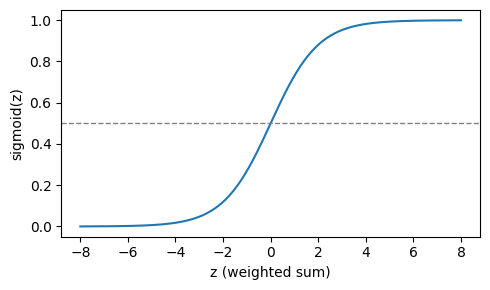

In [9]:
def sigmoid(z):
    return 1 / (1 + np.exp(-np.clip(z, -30, 30)))

z = np.linspace(-8, 8, 200)
fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(z, sigmoid(z))
ax.axhline(0.5, color="gray", linestyle="--", linewidth=1)
ax.set_xlabel("z (weighted sum)")
ax.set_ylabel("sigmoid(z)")
plt.tight_layout()

The target of the model is the binary label $y$ (1 for `Thai`, 0 for `not Thai`), that we take from the binary scheme that we defined at the beginning. Nothing is learned yet: the weights are all zero, and the model gives probability 0.5 to every recipe. The next question is how to change the weights to make the probabilities better.

### The loss

To learn, we need a number that says **how wrong** a model is, so that we can try to make it smaller. Our model returns a probability, and the label is a distribution that gives probability 1 to the right class. The natural way to compare them is to look at the probability that the model gave to the **right** class, $p$ if the recipe is Thai and $1 - p$ if it is not, and to take its negative logarithm. Over the $n$ recipes of the training set we take the average:

$$L = -\frac{1}{n} \sum_{i=1}^{n} \big[\, y_i \log p_i + (1 - y_i) \log (1 - p_i) \,\big]$$

This is the **binary cross-entropy**. It is small when the model is confident and right, and it grows very fast when the model is confident and wrong:

In [10]:
def binary_cross_entropy(p, y, eps=1e-12):
    p = np.clip(p, eps, 1 - eps)
    return -np.mean(y * np.log(p) + (1 - y) * np.log(1 - p))

pd.DataFrame({"p (Thai)": [0.99, 0.9, 0.5, 0.1, 0.01]}).assign(**{
    "loss, if the recipe is Thai": lambda d: [binary_cross_entropy(np.array([p]), np.array([1])) for p in d["p (Thai)"]],
    "loss, if it is not Thai": lambda d: [binary_cross_entropy(np.array([p]), np.array([0])) for p in d["p (Thai)"]],
}).style.format(precision=3).hide(axis="index")

p (Thai),"loss, if the recipe is Thai","loss, if it is not Thai"
0.990,0.010,4.605
0.900,0.105,2.303
0.500,0.693,0.693
0.100,2.303,0.105
0.010,4.605,0.010


A model that gives 0.5 to every recipe (the model that we have before training) pays $\log 2 = 0.693$ on each recipe, whatever the class. If the model says `Thai` with probability 0.9 and the recipe is Thai, the loss is 0.105. If it says the same and the recipe is *not* Thai, the loss is 2.303, twenty times more. The loss punishes the errors that are made with confidence much more than the uncertain ones, and it is a way of asking a model not only to be right, but to know how much it can trust itself.

### The gradient

The loss is a function of the weights $w$ and of the bias $b$. To reduce it we look at how it changes when we change each weight, that is, at the **gradient**, and we move the weights in the opposite direction. For the sigmoid and the cross-entropy the gradient has a very simple form: if $e_i = p_i - y_i$ is the error of the model on the recipe $i$ (a number between $-1$ and $1$),

$$\frac{\partial L}{\partial w_j} = \frac{1}{n} \sum_{i=1}^{n} e_i \, x_{ij} \qquad \frac{\partial L}{\partial b} = \frac{1}{n} \sum_{i=1}^{n} e_i$$

The weight of a term grows when the term is in the recipes on which the model underestimates the probability of `Thai` ($e_i < 0$), and it decreases when the term is in the recipes on which it is overestimated. Every recipe *votes* on the weights of the terms that it contains, in proportion to its error and to the weight of the term.

In [11]:
def gradient(X, y, w, b):
    error = sigmoid(X @ w + b) - y
    return X.T @ error / len(y), error.mean()

We can check the formula against a numerical estimate of the derivative, $\big(L(w + \epsilon) - L(w - \epsilon)\big) / 2\epsilon$, for some weights, starting from random values.

In [12]:
y = b_labels
y_train, y_validation, y_test = y[train], y[validation], y[test]

rng = np.random.default_rng(0)
w, b = rng.normal(scale=0.1, size=X_train.shape[1]), 0.1
grad_w, grad_b = gradient(X_train, y_train, w, b)

def loss(w, b):
    return binary_cross_entropy(sigmoid(X_train @ w + b), y_train)

checks = []
for j in rng.choice(X_train.shape[1], 4, replace=False):
    step = np.zeros_like(w)
    step[j] = 1e-5
    checks.append({"term": vocabulary[j], "formula": grad_w[j],
                   "numerical": (loss(w + step, b) - loss(w - step, b)) / 2e-5})

pd.DataFrame(checks).style.format(precision=6).hide(axis="index")

term,formula,numerical
frozen,0.002511,0.002511
pearl,0.000108,0.000108
instant,0.001253,0.001253
sheet,0.000407,0.000407


### Learning

The training is a loop. At each step we compute the gradient on the whole training set and we move the weights by a small step in the opposite direction, where the size of the step is the **learning rate** $\eta$:

$$w \leftarrow w - \eta \, \frac{\partial L}{\partial w} \qquad b \leftarrow b - \eta \, \frac{\partial L}{\partial b}$$

A complete pass over the training set is an **epoch**. At the end of each epoch we record the loss on the training set and the loss on the validation set, that the model never uses to change its weights. We try three learning rates.

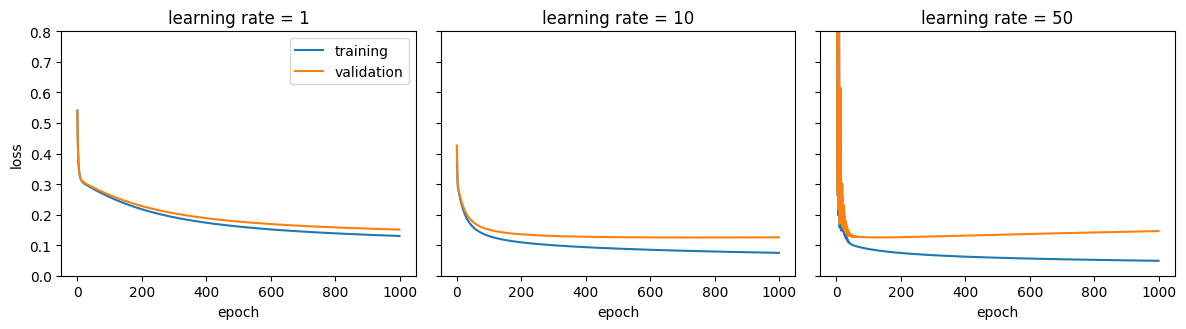

In [13]:
def train_binary(X, y, X_val, y_val, learning_rate, epochs):
    w, b = np.zeros(X.shape[1]), 0.0
    history = []
    for epoch in range(epochs):
        grad_w, grad_b = gradient(X, y, w, b)
        w -= learning_rate * grad_w
        b -= learning_rate * grad_b
        history.append((binary_cross_entropy(sigmoid(X @ w + b), y),
                        binary_cross_entropy(sigmoid(X_val @ w + b), y_val)))
    return w, b, np.array(history)

fig, ax = plt.subplots(ncols=3, figsize=(12, 3.4), sharey=True)
runs = {}
for a, learning_rate in zip(ax, [1, 10, 50]):
    runs[learning_rate] = train_binary(X_train, y_train, X_validation, y_validation, learning_rate, epochs=1000)
    history = runs[learning_rate][2]
    a.plot(history[:, 0], label="training")
    a.plot(history[:, 1], label="validation")
    a.set_title(f"learning rate = {learning_rate}")
    a.set_xlabel("epoch")
ax[0].set_ylabel("loss")
ax[0].set_ylim(0, 0.8)
ax[0].legend()
plt.tight_layout()

The three runs show three different behaviours.

- With a learning rate of **1** the steps are too small: after 1,000 epochs the loss is still going down, and the model has not finished learning.
- With **10** the loss goes down fast and, after about 200 epochs, the validation loss is almost flat (0.126). The training loss keeps decreasing slowly (0.075 at the end): the two curves separate.
- With **50** the steps are too large, and in the first epochs the loss jumps around, even at values much higher than the starting point. Then the model settles, but the validation loss *increases* again (from 0.126 to 0.146) while the training loss goes down (to 0.049). This is **overfitting**: the model has 768 weights and 3,209 recipes, and it starts to adapt to the peculiarities of the training recipes, that do not help on the others.

From now on we use a learning rate of 10.

### The output is a distribution

We take the model trained with a learning rate of 10. On the validation recipes it returns a probability of being Thai. This is what the probabilities look like, separately for the Thai and for the non-Thai recipes (the vertical axis is logarithmic, because the two classes are very different in size).

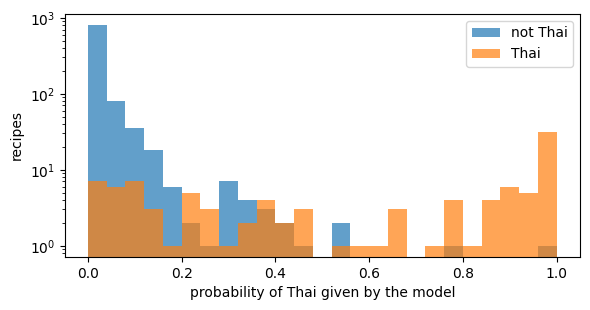

In [14]:
w_thai, b_thai, _ = runs[10]
p_validation = sigmoid(X_validation @ w_thai + b_thai)

fig, ax = plt.subplots(figsize=(6, 3.2))
bins = np.linspace(0, 1, 26)
ax.hist(p_validation[y_validation == 0], bins=bins, alpha=0.7, label="not Thai")
ax.hist(p_validation[y_validation == 1], bins=bins, alpha=0.7, label="Thai")
ax.set_yscale("log")
ax.set_xlabel("probability of Thai given by the model")
ax.set_ylabel("recipes")
ax.legend()
plt.tight_layout()

Most of the non-Thai recipes get a probability lower than 0.1. The Thai recipes are spread over the whole interval: a group is close to 1, but there is a long tail of recipes that the model considers unlikely to be Thai. The model does not say *Thai* or *not Thai*: it says *how much*. To obtain a label we have to choose a **threshold**, and the natural choice is 0.5: the recipe is Thai if the model gives to `Thai` more than half of the probability.

In [15]:
predicted = (p_validation > 0.5).astype(int)

pd.DataFrame({"accuracy": {"model, threshold 0.5": (predicted == y_validation).mean(),
                           "always answering `not Thai`": (y_validation == 0).mean()}}
             ).style.format("{:.1%}")

,accuracy
"model, threshold 0.5",95.5%
always answering `not Thai`,90.5%


With this threshold the model is right on 95.5% of the recipes. It looks like a good result, but look at the second row: a model that ignores the ingredients and answers `not Thai` to every recipe is right 90.5% of the times, because only 9.5% of the recipes are Thai. The model improves on this baseline by five points, and the **accuracy** does not tell us how well the model recognizes the recipes that we are looking for. We will come back to this in the evaluation.

### Reading the weights

The model has one weight for each term. It is a small model, and we can look inside: these are the terms with the highest and the lowest weights.

In [16]:
order = np.argsort(w_thai)

pd.concat({
    "towards Thai": pd.DataFrame({"term": vocabulary[order[::-1][:12]], "weight": w_thai[order[::-1][:12]]}),
    "away from Thai": pd.DataFrame({"term": vocabulary[order[:12]], "weight": w_thai[order[:12]]}),
}, axis=1).style.format(precision=2).hide(axis="index")

The terms that push a recipe towards `Thai` are the ones that we would expect: `fish`, `lemongrass`, `peanut`, `coconut`, `lime`, `basil`, `shallot`, and `thai` itself (from ingredients such as *Thai basil* or *Thai chile*). The weights are large because the vectors have unit length and only about 15 non-zero terms, so each term contributes with a small value.

But some weights need care. `sauce` has a high weight only because our tokenization splits *fish sauce* in two tokens: alone, it is a generic term. And `soy` is **away** from Thai, even if soy sauce is used in Thai recipes: the model is not comparing Thai with the *absence* of a cuisine, it is comparing it with all the other recipes, and in these there are the Chinese and the Japanese ones, in which soy sauce is even more frequent (as `mirin` and `sherry`, that are pushed away for the same reason). A weight is not a property of a term: it depends on the classes that we compare and on the other terms that carry the same information. We will come back to this when we discuss how to explain the predictions of a model.

## Many classes: the softmax

### From one probability to a distribution

With ten classes we do not have a single probability, but a distribution: ten probabilities that sum to one. The model has now **one weight vector for each class**, that is, a matrix $W$ with one column per class, and a bias for each class. For each recipe the model computes ten weighted sums $z_c$ (one per class), and the **softmax** turns them into a distribution:

$$P(c \mid x) = \frac{e^{z_c}}{\sum_{c'} e^{z_{c'}}} \qquad z_c = \sum_j W_{jc} x_j + b_c$$

The exponential makes every value positive, and the division makes them sum to one. With two classes the softmax is the sigmoid. The loss is the negative logarithm of the probability given to the right class, averaged over the recipes (the **cross-entropy**), and the gradient has the same form as before, with the vector of the errors $P(c \mid x_i) - y_{ic}$, where $y_i$ is the one-hot vector of the recipe: the code is almost identical to the binary case.

Minimum of the validation loss: 0.981, at epoch 579
At the end of the training: 0.472 (training), 1.027 (validation)


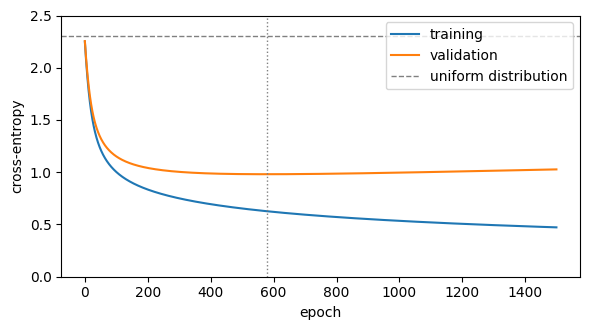

In [17]:
def softmax(Z):
    E = np.exp(Z - Z.max(axis=1, keepdims=True))
    return E / E.sum(axis=1, keepdims=True)

def cross_entropy(P, Y, eps=1e-12):
    return -np.mean(np.log(np.clip((P * Y).sum(axis=1), eps, 1)))

def train_softmax(X, Y, X_val, Y_val, learning_rate, epochs):
    W, b = np.zeros((X.shape[1], Y.shape[1])), np.zeros(Y.shape[1])
    history = []
    for epoch in range(epochs):
        error = softmax(X @ W + b) - Y
        W -= learning_rate * (X.T @ error) / len(Y)
        b -= learning_rate * error.mean(axis=0)
        history.append((cross_entropy(softmax(X @ W + b), Y), cross_entropy(softmax(X_val @ W + b), Y_val)))
    return W, b, np.array(history)

Y_train, Y_validation, Y_test = (np.eye(len(classes))[labels[s]] for s in (train, validation, test))
W, b, history = train_softmax(X_train, Y_train, X_validation, Y_validation, learning_rate=10, epochs=1500)

best_epoch = history[:, 1].argmin() + 1
fig, ax = plt.subplots(figsize=(6, 3.4))
ax.plot(history[:, 0], label="training")
ax.plot(history[:, 1], label="validation")
ax.axhline(np.log(len(classes)), color="gray", linestyle="--", linewidth=1, label="uniform distribution")
ax.axvline(best_epoch, color="gray", linestyle=":", linewidth=1)
ax.set_xlabel("epoch")
ax.set_ylabel("cross-entropy")
ax.set_ylim(0, 2.5)
ax.legend()
plt.tight_layout()
print(f"Minimum of the validation loss: {history[:, 1].min():.3f}, at epoch {best_epoch}")
print(f"At the end of the training: {history[-1, 0]:.3f} (training), {history[-1, 1]:.3f} (validation)")

The validation loss goes down until epoch 579 (0.981), and then it starts to grow slowly, while the training loss keeps going down (0.472 at epoch 1500). This is the overfitting that we already saw in the binary problem, and it is stronger, because the model has now ten times more weights (7,680) for the same recipes. The validation set is used here for a decision: **we stop the training at the epoch in which the validation loss is at its minimum** (*early stopping*).

The dashed line is the cross-entropy of the model before training, that gives the same probability (0.1) to all the classes: $\log 10 = 2.30$. The trained model goes down to 0.98. In a moment we will see how to read this number.

In [18]:
W_softmax, b_softmax, _ = train_softmax(X_train, Y_train, X_validation, Y_validation, learning_rate=10, epochs=best_epoch)
P_validation = softmax(X_validation @ W_softmax + b_softmax)

print(f"Accuracy on the validation set: {(P_validation.argmax(axis=1) == labels[validation]).mean():.1%}")

Accuracy on the validation set: 67.0%


On the validation set the model is right on 67.0% of the recipes, with ten classes: a random answer is right 10% of the times, and the largest class is 11.4% of the recipes. Note that the validation set was used to choose the epoch, so this number is a bit optimistic. The **test set** has not been used, and it is for the final comparison.

### The distribution for a recipe

The model does not give us an answer, it gives us a distribution. Here are three recipes of the validation set: the one for which the model is most confident in a correct prediction, the one for which it is least sure, and the one for which it is most confident *and wrong*.

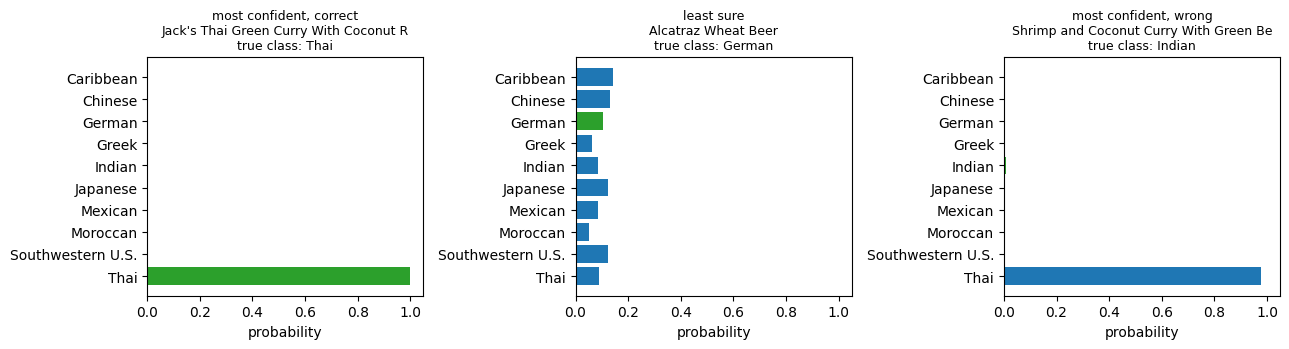

In [19]:
top = P_validation.max(axis=1)
correct = P_validation.argmax(axis=1) == labels[validation]

picked = {"most confident, correct": np.where(correct)[0][top[correct].argmax()],
          "least sure": top.argmin(),
          "most confident, wrong": np.where(~correct)[0][top[~correct].argmax()]}

fig, ax = plt.subplots(ncols=3, figsize=(13, 3.6), sharex=True)
for a, (name, i) in zip(ax, picked.items()):
    colors = ["tab:green" if c == labels[validation][i] else "tab:blue" for c in range(len(classes))]
    a.barh(classes, P_validation[i], color=colors)
    a.invert_yaxis()
    title = html.unescape(recipes[indices[validation[i]]]["title"])
    a.set_title(f"{name}\n{title[:38]}\ntrue class: {classes[labels[validation][i]]}", fontsize=9)
    a.set_xlabel("probability")
plt.tight_layout()

The green bar is the true class of the recipe.

- The first recipe is a Thai green curry, and the model gives to `Thai` a probability that is almost 1.
- The second is a wheat beer, with the ingredients of a beer: no cuisine is recognized, and the probability is spread among all the classes, with a maximum of 0.14. The true class is `German`, with 0.10. The model does not know, and it tells us that.
- The third is a recipe of shrimp and coconut curry, which is `Indian` in the data, and the model says `Thai` with a probability of 0.98, and only 0.01 to `Indian`. It is a mistake, but a very reasonable one: coconut milk and curry are also Thai. This is what a model that learns from the ingredients can do, and it is confident because these ingredients are, in the training set, much more frequent in Thai recipes.

The distribution contains more information than the class with the highest probability: it tells us when the model is sure and when it is not, and which classes it is confusing. The label that the model returns is the **highest bar**, and it is only a summary of the distribution.

### The limits of this model

The sigmoid and the softmax are not linear functions, but they are applied to a score that is: the score of a class is a **weighted sum of the terms**, in which each term counts on its own, whatever the other terms in the recipe. The activation only turns the scores into probabilities, without changing which class has the highest one, and the boundary between two classes is still a linear one (a hyperplane in the space of the terms). We can call it a *linear model with a probabilistic output*.

Such a model can learn that `coconut` and `lemongrass` are Thai, but not that `coconut` is Thai *when it is with* `lemongrass`, and Caribbean when it is with `rum`. It is also a model in which every term is a separate dimension, and two terms that are similar, such as `lime` and `lemon`, have nothing in common for the model: their weights are learned separately and each needs enough examples.

The next step is to add a **hidden layer** between the input and the output. It is the point in which the network stops looking at the terms one by one, and it will change the way in which the recipe is represented.

## A hidden layer, with PyTorch

### The same model, in PyTorch

To build larger networks we stop writing the gradient by hand. **PyTorch** does two things for us: it stores the data in **tensors** (arrays that can also live on a GPU), and, with **automatic differentiation**, it records the operations that produce the loss and computes the gradient of the loss with respect to every parameter (`loss.backward()`), by applying the chain rule backwards through the network (*backpropagation*). We write the model and the loss; PyTorch computes the gradient.

To see that nothing has changed, we build in PyTorch the model without hidden layers, `nn.Linear` (the weighted sum $XW + b$) with the cross-entropy loss, we start from the same weights (zeros), and we train it with the same procedure (gradient descent on the whole training set, learning rate 10) for the same number of epochs.

In [20]:
import copy

import torch
from torch import nn

def to_tensor(X):
    return torch.tensor(X.toarray(), dtype=torch.float32)

x_train, x_validation, x_test = to_tensor(X_train), to_tensor(X_validation), to_tensor(X_test)
t_train, t_validation, t_test = (torch.tensor(labels[s]) for s in (train, validation, test))
loss_fn = nn.CrossEntropyLoss()

linear = nn.Linear(X_train.shape[1], len(classes))
nn.init.zeros_(linear.weight)
nn.init.zeros_(linear.bias)
optimizer = torch.optim.SGD(linear.parameters(), lr=10)

for epoch in range(best_epoch):
    optimizer.zero_grad()
    loss = loss_fn(linear(x_train), t_train)
    loss.backward()
    optimizer.step()

with torch.no_grad():
    print(f"Validation loss, PyTorch: {loss_fn(linear(x_validation), t_validation).item():.4f}")
print(f"Validation loss, NumPy:   {cross_entropy(P_validation, Y_validation):.4f}")
print(f"Largest difference between the weights: {np.abs(linear.weight.detach().numpy().T - W_softmax).max():.1e}")

Validation loss, PyTorch: 0.9810
Validation loss, NumPy:   0.9810
Largest difference between the weights: 3.9e-06


The two models are the same: the validation loss is identical (0.9810), and the weights differ by less than $10^{-5}$, the rounding of the 32-bit numbers that PyTorch uses. The gradient that PyTorch computes by automatic differentiation is the one that we derived by hand. From now on we let it do the work: for a network with several layers we would not want to write the derivatives ourselves.

### Adding a hidden layer

Now the change. Between the input and the output we put a **hidden layer** of 64 units:

$$h = \text{ReLU}(x W_1 + b_1) \qquad z = h W_2 + b_2 \qquad P(c \mid x) = \text{softmax}(z)$$

The first layer is a set of 64 neurons, each one with a weight for each of the 768 terms. Its output is a vector $h$ of 64 numbers: **a new representation of the recipe**, that the network builds by itself. The second layer is what we had before, with the difference that its input is $h$ and not the terms.

Between the two layers there is an **activation function**, the ReLU: $\text{ReLU}(u) = \max(0, u)$. It cannot be omitted. Two linear layers one after the other, $(xW_1)W_2$, are the same as a single linear layer with the matrix $W_1 W_2$, and we would have the model of the previous section with more parameters. The ReLU is the non-linearity that makes the hidden layer useful: the units can respond to combinations of terms.

In [21]:
torch.manual_seed(0)
hidden = nn.Sequential(nn.Linear(X_train.shape[1], 64), nn.ReLU(), nn.Linear(64, len(classes)))

print(hidden)
print(f"Parameters: {sum(p.numel() for p in hidden.parameters()):,} (linear model: {sum(p.numel() for p in linear.parameters()):,})")

Sequential(
  (0): Linear(in_features=768, out_features=64, bias=True)
  (1): ReLU()
  (2): Linear(in_features=64, out_features=10, bias=True)
)
Parameters: 49,866 (linear model: 7,690)


We train it with the same idea (minimize the cross-entropy) but with two changes that are standard for larger networks. The gradient is computed on **mini-batches** of 64 recipes, and not on the whole training set: an epoch has many small steps, and each one is a noisy but cheap estimate of the gradient. The steps are made by **Adam**, a variant of the gradient descent that adapts the learning rate of every parameter. As before, we look at the loss on the validation set and we keep the model of the best epoch.

Minimum of the validation loss: 0.953, at epoch 51
At the end of the training: 0.375 (training), 1.052 (validation)


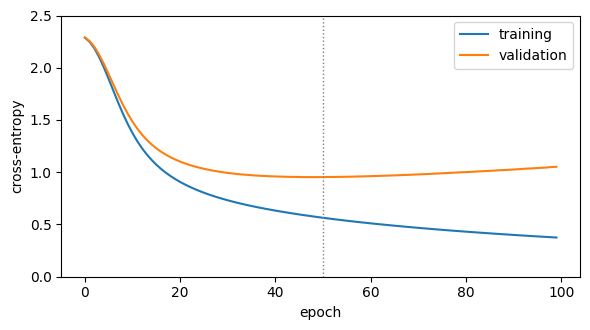

In [22]:
def train_network(model, learning_rate, epochs, batch_size=64, seed=0):
    generator = torch.Generator().manual_seed(seed)
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    history, best = [], (np.inf, None, 0)
    for epoch in range(epochs):
        model.train()
        order = torch.randperm(len(x_train), generator=generator)
        for start in range(0, len(order), batch_size):
            batch = order[start:start + batch_size]
            optimizer.zero_grad()
            loss_fn(model(x_train[batch]), t_train[batch]).backward()
            optimizer.step()
        model.eval()
        with torch.no_grad():
            history.append((loss_fn(model(x_train), t_train).item(), loss_fn(model(x_validation), t_validation).item()))
        if history[-1][1] < best[0]:
            best = (history[-1][1], copy.deepcopy(model.state_dict()), epoch + 1)
    model.load_state_dict(best[1])
    return np.array(history), best[2]

history_hidden, best_epoch_hidden = train_network(hidden, learning_rate=3e-4, epochs=100)

fig, ax = plt.subplots(figsize=(6, 3.4))
ax.plot(history_hidden[:, 0], label="training")
ax.plot(history_hidden[:, 1], label="validation")
ax.axvline(best_epoch_hidden - 1, color="gray", linestyle=":", linewidth=1)
ax.set_xlabel("epoch")
ax.set_ylabel("cross-entropy")
ax.set_ylim(0, 2.5)
ax.legend()
plt.tight_layout()
print(f"Minimum of the validation loss: {history_hidden[:, 1].min():.3f}, at epoch {best_epoch_hidden}")
print(f"At the end of the training: {history_hidden[-1, 0]:.3f} (training), {history_hidden[-1, 1]:.3f} (validation)")

The network reaches the minimum of the validation loss at epoch 51 and after that it overfits, with the same pattern that we saw before: the training loss goes down to 0.375 and the validation loss goes back from 0.953 to 1.052. With 49,866 parameters for 3,209 recipes, the model has plenty of room to memorize the training set. (The epochs of this training are not comparable with the ones of the previous one: here every epoch is made of 51 steps on mini-batches, and before it was a single step on the whole set.)

In [23]:
with torch.no_grad():
    P_hidden = torch.softmax(hidden(x_validation), dim=1).numpy()

pd.DataFrame({
    "linear": {"parameters": sum(p.numel() for p in linear.parameters()), "best epoch": best_epoch,
               "validation loss": cross_entropy(P_validation, Y_validation),
               "accuracy": (P_validation.argmax(axis=1) == labels[validation]).mean()},
    "hidden layer": {"parameters": sum(p.numel() for p in hidden.parameters()), "best epoch": best_epoch_hidden,
                     "validation loss": cross_entropy(P_hidden, Y_validation),
                     "accuracy": (P_hidden.argmax(axis=1) == labels[validation]).mean()},
}).T.style.format({"parameters": "{:,.0f}", "best epoch": "{:.0f}", "validation loss": "{:.3f}", "accuracy": "{:.1%}"})

,parameters,best epoch,validation loss,accuracy
linear,"7,690",579,0.981,67.0%
hidden layer,"49,866",51,0.953,67.1%


The hidden layer is better, but not by much: the validation loss goes from 0.981 to 0.953, and the accuracy is the same (67.0% and 67.1%), with a model that has 6.5 times more parameters. With 3,209 recipes and the ingredients as the only information, the linear model is already close to what we can extract, and a hidden layer is not a way of improving every result. The two models were trained with different optimizers and learning rates, so this is a first look: we will compare them properly, on the test set and with the same protocol, in the evaluation.

The interesting difference is not in the numbers, but in what the hidden layer does to the representation of the recipes.

### From sparse to dense

The most important difference between the two models is not in the numbers of the table, but in what is inside the network. In the model without hidden layers the input of the classifier is the vector of the terms: 768 dimensions, one for each term, almost all zeros. In the model with the hidden layer the classifier receives $h$, that has 64 dimensions. Let's see how the two representations of the validation recipes differ.

In [24]:
with torch.no_grad():
    H_train = torch.relu(hidden[0](x_train)).numpy()
    H_validation = torch.relu(hidden[0](x_validation)).numpy()

pd.DataFrame({
    "input (TF-IDF)": {"dimensions": X_validation.shape[1], "non-zero values for each recipe": X_validation.getnnz(axis=1).mean(),
                       "share of non-zero values": X_validation.nnz / np.prod(X_validation.shape)},
    "hidden layer": {"dimensions": H_validation.shape[1], "non-zero values for each recipe": (H_validation > 0).sum(axis=1).mean(),
                     "share of non-zero values": (H_validation > 0).mean()},
}).T.style.format({"dimensions": "{:.0f}", "non-zero values for each recipe": "{:.1f}", "share of non-zero values": "{:.1%}"})

,dimensions,non-zero values for each recipe,share of non-zero values
input (TF-IDF),768,14.1,1.8%
hidden layer,64,57.2,89.4%


The input is a **sparse** vector: 768 dimensions, of which a recipe has 14 non-zero (1.8%), and every dimension is a term. The hidden layer returns a **dense** vector: 64 dimensions, 57 of them non-zero on average (89%), that is twelve times shorter, and in which no dimension is a term. Each one of the 64 numbers depends on many terms at the same time. The network has moved the recipe from a space in which it is described by *which terms it contains* to a space that it has built by itself.

### A vector for every term

Where do the 64 numbers of a recipe come from? Before the ReLU, the hidden layer computes $x W_1 + b_1$, and $x$ has only a few non-zero values, the TF-IDF weights of the terms of the recipe. The result is a **weighted sum of rows of $W_1$**, one row for each term of the recipe: every term has a *vector of 64 numbers*, and the recipe is the sum of the vectors of its terms, scaled by their weights. The matrix $W_1$ is a table of 768 dense vectors, one for each term, that the network has learned.

In the space of the input, every term is a separate axis: any two terms are orthogonal, and none of them is closer to another. Are the vectors of $W_1$ different? We look, for some terms, at the terms with the most similar vector (cosine similarity).

In [25]:
term_vectors = hidden[0].weight.detach().numpy().T
unit_vectors = term_vectors / np.linalg.norm(term_vectors, axis=1, keepdims=True)
term_index = {term: i for i, term in enumerate(vocabulary)}

def neighbors(term, k=6):
    similarity = unit_vectors @ unit_vectors[term_index[term]]
    return ", ".join(vocabulary[j] for j in np.argsort(-similarity)[1:k + 1])

pd.DataFrame({"nearest terms": {t: neighbors(t) for t in ["mirin", "feta", "tortilla", "lemongrass", "rum", "lime", "cilantro"]}}
             ).style.set_properties(**{"text-align": "left"})

,nearest terms
mirin,"sake, wasabi, bonito, nori, mugwort, kikkoman"
feta,"orzo, farina, halloumi, phyllo, metaxa, kalamata"
tortilla,"salsa, poblano, mexican, 6, manchego, ancho"
lemongrass,"fish, crunchy, thai, tea, nam, pla"
rum,"pimiento, plantain, thyme, parboil, yucca, scotch"
lime,"boston, distil, coarse, papaya, fettuccine, snapper"
cilantro,"anaheim, chili, catfish, chilie, monterey, jack"


For many terms the answer is yes, and in a way that is easy to read. `mirin` is close to `sake`, `wasabi`, `bonito` and `nori` (Japanese); `feta` to `orzo`, `halloumi`, `phyllo` and `kalamata` (Greek); `tortilla` to `salsa`, `poblano` and `ancho` (Mexican); `lemongrass` to `fish`, `thai`, `nam` and `pla`; `rum` to `plantain` and `yucca` (Caribbean). The network has never been told that these terms are related. It has been told the cuisine of the recipes, and to do its job it had to treat in a similar way the terms that appear in the same kind of recipes.

There are two limits. First, the geometry of this space reflects the **task**: two terms are close if they say the same thing *about the cuisine*, not if they have a similar meaning (`feta` and `orzo` are not synonyms, they are both Greek). Second, it works for the terms that carry information on the class and that are frequent enough: for `lime`, that occurs in many cuisines, or for `cilantro`, the neighbors are almost noise, because the network has no reason to give a precise position to a term that does not help to decide.

This is the idea that we will develop in the next lessons: **dense vectors for the terms, learned as a by-product of a task**. Here the task is the classification of the recipes. Word2Vec will turn the idea around, and design a task whose only purpose is to produce good vectors.

### A space for the recipes

The same happens to the recipes. In the space of the input two recipes are close only if they share many of the same terms. In the hidden space they can be close because they use terms that the network has learned to treat in a similar way. To see it we look, for each validation recipe, at its ten nearest recipes of the training set (cosine similarity), and we count how many of them have the same cuisine.

In [26]:
from sklearn.neighbors import NearestNeighbors

spaces = {"TF-IDF (768 dimensions)": (X_train.toarray(), X_validation.toarray()),
          "hidden layer (64 dimensions)": (H_train, H_validation)}

rows = {}
for name, (A_train, A_validation) in spaces.items():
    nearest = NearestNeighbors(n_neighbors=10, metric="cosine").fit(A_train).kneighbors(A_validation, return_distance=False)
    rows[name] = {"nearest recipes with the same cuisine": (labels[train][nearest] == labels[validation][:, None]).mean()}

pd.DataFrame(rows).T.style.format("{:.1%}")

,nearest recipes with the same cuisine
TF-IDF (768 dimensions),46.1%
hidden layer (64 dimensions),60.6%


In the space of the TF-IDF, 46.1% of the ten nearest recipes have the same cuisine. In the hidden space, 60.6%. The recipes on which we measure it are the validation ones, that were not used to train the network, so the hidden layer did not memorize them. Of course this is what we asked it to do, because the network was trained to tell the cuisines apart: it is an example of a representation that is *built for a task*.

The two spaces have too many dimensions to be seen, but we can project them on a plane (with t-SNE, that keeps close the points that are close in the original space) and color the recipes by cuisine.

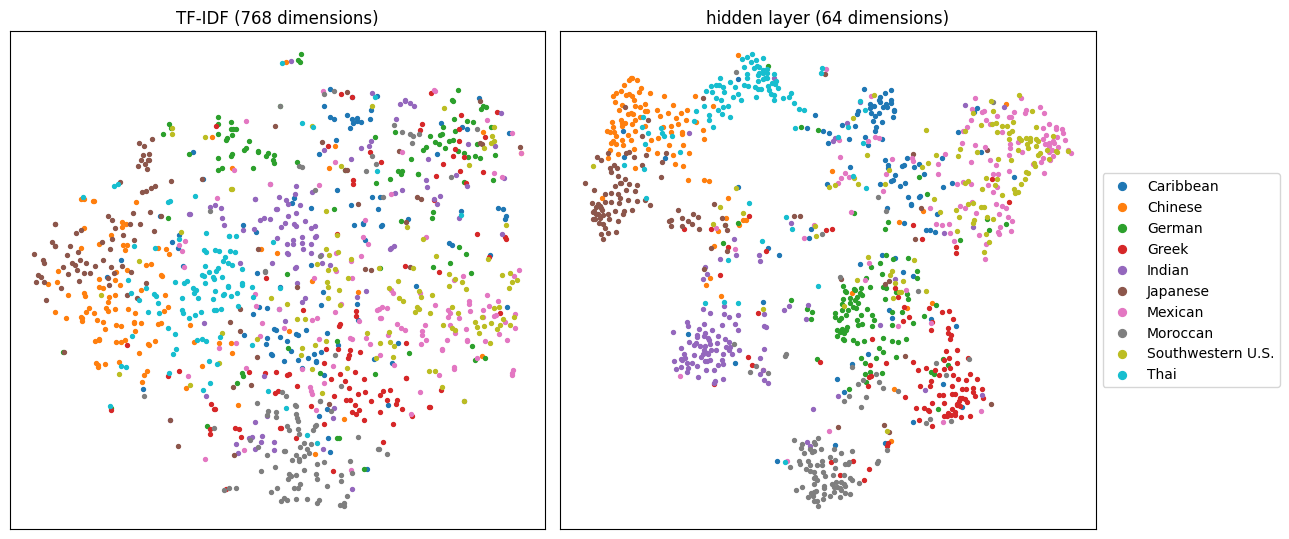

In [27]:
from sklearn.manifold import TSNE

fig, ax = plt.subplots(ncols=2, figsize=(13, 5.5))
for a, (name, (_, A_validation)) in zip(ax, spaces.items()):
    xy = TSNE(perplexity=30, metric="cosine", init="random", random_state=0).fit_transform(A_validation)
    for c, cuisine in enumerate(classes):
        selected = labels[validation] == c
        a.scatter(xy[selected, 0], xy[selected, 1], s=8, color=plt.cm.tab10(c), label=cuisine)
    a.set_title(name)
    a.set_xticks([])
    a.set_yticks([])
ax[1].legend(loc="center left", bbox_to_anchor=(1, 0.5), markerscale=2)
plt.tight_layout()

In the space of the TF-IDF (left) the cuisines are mixed, with only a few areas that are recognizable (the Moroccan recipes at the bottom, the Chinese and the Japanese on the left). In the hidden space (right) the recipes form separate groups, one for each cuisine, and the confusions that remain are sensible ones: `Mexican` and `Southwestern U.S.` overlap, as they share most of the ingredients, and the Asian cuisines are near to one another. A projection on a plane distorts the distances, so this is an illustration and not a measure: the measure is the one of the table above.

### What the hidden layer gave us

We started from a sparse representation, in which every term is an independent dimension, and we obtained a dense and compact one, in which terms and recipes have a position and a neighborhood. The classifier of the last layer is the same as before: a weighted sum followed by a softmax. What changed is the space in which it works. This is the reason why the layers of a network are often described as **learning a representation**: the classification is done by the last layer, on a representation that all the previous layers have constructed.

Now we have two models, and each one returns a distribution over the ten cuisines. It is time to ask how to say which one is better.

## The distribution as an object: perplexity and decoding

### How surprised is the model?

Until now we have judged a model by the loss that we minimize, without saying what it means. The cross-entropy is the average of $-\log P(c_i \mid x_i)$, where $c_i$ is the true class of the recipe $i$. The quantity $-\log p$ is the **surprisal** of an event that the model considered to have probability $p$: it is 0 if the model was sure ($p = 1$), it is small if the model expected it, and it becomes large when the true class was something that the model considered very unlikely. The cross-entropy is the surprisal of the model, on average, when it sees the true answers.

The cross-entropy is not easy to interpret: what does 0.953 mean? The **perplexity** is the same number, on a scale that is easier to read:

$$\text{perplexity} = e^{\,\text{cross-entropy}}$$

It is the number of **equally likely classes** among which the model hesitates. A model that gives the same probability to the ten cuisines has a perplexity of 10, and a model that always puts all the probability on the true class has a perplexity of 1. The perplexity always lies between 1 and the number of classes (unless the model is confidently wrong, in which case it can be much larger).

We compute it, on the validation set, for the two models and for two models that do not read the recipe: one that always answers with the uniform distribution and one that always answers with the distribution of the classes in the training set (the **prior**).

In [28]:
with torch.no_grad():
    Z = {"linear": X_validation @ W_softmax + b_softmax, "hidden layer": hidden(x_validation).numpy()}

prior = np.bincount(labels[train], minlength=len(classes)) / len(train)
distributions = {
    "uniform": np.full((len(validation), len(classes)), 1 / len(classes)),
    "prior": np.tile(prior, (len(validation), 1)),
    "linear": softmax(Z["linear"]),
    "hidden layer": softmax(Z["hidden layer"]),
}

rows = {}
for name, P in distributions.items():
    cross = cross_entropy(P, Y_validation)
    rows[name] = {"cross-entropy": cross, "perplexity": np.exp(cross),
                  "accuracy": np.nan if name == "uniform" else (P.argmax(axis=1) == labels[validation]).mean()}

pd.DataFrame(rows).T.style.format({"cross-entropy": "{:.3f}", "perplexity": "{:.2f}", "accuracy": "{:.1%}"}, na_rep="-")

,cross-entropy,perplexity,accuracy
uniform,2.303,10.00,-
prior,2.301,9.99,11.4%
linear,0.981,2.67,67.0%
hidden layer,0.953,2.59,67.1%


The uniform model has a perplexity of exactly 10 (its cross-entropy is $\log 10 = 2.303$). The prior, that answers with the proportions of the classes in the training set, is almost the same (9.99): the classes are nearly balanced, so knowing how many recipes there are for each cuisine is not of much help. Its accuracy is 11.4%, the share of the largest class.

The two networks are on a completely different scale: 2.67 for the linear model and 2.59 for the one with the hidden layer. Reading the numbers as *choices*, the models that do not look at the recipe hesitate among ten cuisines, and the networks among about two and a half. It is the same information as the cross-entropy (0.981 and 0.953), in a form that we can picture.

This is the way in which the quality of a **language model** is measured. There, the classes are the words of the vocabulary and the input is the text that precedes: the model gives a probability to each possible next word, and a perplexity of 20 means that, on average, it hesitates among 20 words. The model that ignores the text and answers with the frequencies of the words is the natural baseline, exactly as the prior is here.

### Where does the surprise come from?

The cross-entropy is an average, and an average can hide how the values are distributed. We look at the surprisal of the single recipes, for the two models.

The 10% of the recipes with the highest surprisal give 36% of the total (linear model).


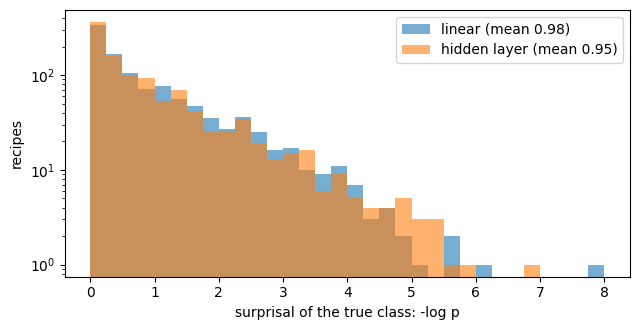

In [29]:
surprisal = {name: -np.log((distributions[name] * Y_validation).sum(axis=1)) for name in ["linear", "hidden layer"]}

fig, ax = plt.subplots(figsize=(6.5, 3.4))
bins = np.linspace(0, 8, 33)
for name, s in surprisal.items():
    ax.hist(s, bins=bins, alpha=0.6, label=f"{name} (mean {s.mean():.2f})")
ax.set_yscale("log")
ax.set_xlabel("surprisal of the true class: -log p")
ax.set_ylabel("recipes")
ax.legend()
plt.tight_layout()

worst = np.sort(surprisal["linear"])[::-1][:len(validation) // 10]
print(f"The 10% of the recipes with the highest surprisal give {worst.sum() / surprisal['linear'].sum():.0%} of the total (linear model).")

Most of the recipes have a low surprisal: the model gave a high probability to the true class. But there is a long tail, up to the recipes for which the true class had a probability of a few thousandths (a surprisal of 5 or more): the 10% of the recipes with the highest surprisal contribute 36% of the total. These are the recipes on which the model was confident and wrong. The two models have similar distributions.

This is the difference with the accuracy. For the accuracy an error is an error, and it counts one whether the true class had a probability of 0.4 or of 0.003. The cross-entropy, and the perplexity, look at the *whole* distribution and punish heavily the errors made with confidence.

### Perplexity and accuracy are different things

The two measures do not always agree. To see it we train the model without hidden layers for a much longer time (1,500 epochs instead of 579): we know that it overfits, but let's look at what happens to the accuracy.

In [30]:
W_long, b_long, _ = train_softmax(X_train, Y_train, X_validation, Y_validation, learning_rate=10, epochs=1500)

rows = {}
for name, P in {"stopped at epoch 579": distributions["linear"],
                "trained for 1500 epochs": softmax(X_validation @ W_long + b_long)}.items():
    cross = cross_entropy(P, Y_validation)
    rows[name] = {"accuracy": (P.argmax(axis=1) == labels[validation]).mean(),
                  "average probability of the answer": P.max(axis=1).mean(),
                  "cross-entropy": cross, "perplexity": np.exp(cross)}

pd.DataFrame(rows).T.style.format({"accuracy": "{:.1%}", "average probability of the answer": "{:.1%}",
                                   "cross-entropy": "{:.3f}", "perplexity": "{:.2f}"})

,accuracy,average probability of the answer,cross-entropy,perplexity
stopped at epoch 579,67.0%,65.1%,0.981,2.67
trained for 1500 epochs,66.0%,70.7%,1.027,2.79


After the long training the accuracy has lost only a point (67.0% and 66.0%), but the model has changed. At epoch 579 the average probability that the model gives to its answer (65.1%) is close to the accuracy (67.0%): the model is a bit *cautious*. After 1,500 epochs it gives to its answer an average probability of 70.7%, while being right less often: it is **overconfident**. The accuracy does not see it, and the perplexity does (from 2.67 to 2.79).

The accuracy evaluates only the top of the distribution, the class that we choose; the perplexity evaluates all the probabilities. When we use the model to *decide*, the first may be enough. When the probabilities are used (to tell how sure the model is, to combine models, to generate), the second is the one that matters. At the end of this section we will see the cleanest example: five models with the same predictions and five different perplexities.

### From the distribution to an answer: greedy and sampling

A classifier has to answer with a class, and the model gives us a distribution. The rule that we have used so far is **greedy decoding**: take the class with the highest probability. It is not the only rule. With **sampling** we *draw* the class at random, with the probabilities of the model: a recipe to which the model gives 0.6 to `Thai` and 0.3 to `Chinese` is answered `Thai` in 6 draws out of 10 and `Chinese` in 3.

The greedy answer is always the same. Let's compare the two rules on the three recipes of the previous section, drawing 10 times for each one.

In [31]:
rng = np.random.default_rng(0)

def sample(P, rng):
    draws = (rng.random((len(P), 1)) > P.cumsum(axis=1)).sum(axis=1)
    return np.minimum(draws, P.shape[1] - 1)

rows = {}
for name, i in picked.items():
    draws = sample(np.tile(P_validation[i], (10, 1)), rng)
    rows[name] = {"recipe": html.unescape(recipes[indices[validation[i]]]["title"])[:34],
                  "true class": classes[labels[validation][i]],
                  "greedy": classes[P_validation[i].argmax()],
                  "10 samples": ", ".join(classes[draws])}

pd.DataFrame(rows).T.style.set_properties(**{"text-align": "left"}).hide(axis="index")

recipe,true class,greedy,10 samples
Jack's Thai Green Curry With Cocon,Thai,Thai,"Thai, Thai, Thai, Thai, Thai, Thai, Thai, Thai, Thai, Thai"
Alcatraz Wheat Beer,German,Caribbean,"Southwestern U.S., Caribbean, Southwestern U.S., Caribbean, Mexican, Chinese, Southwestern U.S., Japanese, German, Greek"
Shrimp and Coconut Curry With Gree,Indian,Thai,"Thai, Thai, Thai, Thai, Thai, Thai, Thai, Thai, Thai, Thai"


For the Thai curry the model is so sure that the ten draws are the same as the greedy answer. The same happens for the shrimp curry, which is a recipe on which the model is confident and *wrong*: sampling does not help, because there is nothing else in the distribution.

The wheat beer is the interesting case. The greedy answer is `Caribbean`, with a probability of 0.14, and it is always the same answer, no matter how many times we ask. The ten draws are spread over seven classes (and, once, the true one, `German`, by luck). The sampling reproduces the **uncertainty** of the model, that greedy decoding hides: choosing `Caribbean` is only a little more justified than choosing any other cuisine.

In [32]:
y_validation_multi = labels[validation]
P = distributions["linear"]
p_true = (P * Y_validation).sum(axis=1)

sampled = np.mean([(sample(P, rng) == y_validation_multi).mean() for _ in range(200)])

pd.DataFrame({"accuracy": {"greedy": (P.argmax(axis=1) == y_validation_multi).mean(),
                           "sampling (mean of 200 repetitions)": sampled,
                           "sampling (expected value: mean probability of the true class)": p_true.mean()}}
             ).style.format("{:.1%}")

,accuracy
greedy,67.0%
sampling (mean of 200 repetitions),54.0%
sampling (expected value: mean probability of the true class),54.0%


Over the whole validation set, sampling is right on 54.0% of the recipes, against 67.0% for the greedy answer. The value is not by chance: the probability of guessing the right class by sampling is *the probability that the model gave to it*, so the expected accuracy of sampling is the average probability of the true class (54.0%, the last row). When the goal is to give the single best answer, as in a classification, greedy is the right choice: it always bets on the most probable class, and sampling gives up thirteen points.

There are tasks in which there is not a single right answer. When a language model has to continue a sentence, many words are good continuations, and always taking the most probable one gives predictable text, while sampling gives variety, at the price of drawing, sometimes, a word that is not a good one. The choice between greedy and sampling will come back when we generate text.

### Temperature

There is a way to change how much the distribution is concentrated without changing the model. The scores $z_c$ are divided by a **temperature** $T$ before the softmax:

$$P_T(c \mid x) = \frac{e^{z_c / T}}{\sum_{c'} e^{z_{c'} / T}}$$

With $T = 1$ we have the distribution of the model. With $T < 1$ the differences between the scores are amplified, and the distribution concentrates on the highest class (at the limit, it becomes the greedy answer). With $T > 1$ they are reduced, and the distribution tends to the uniform one.

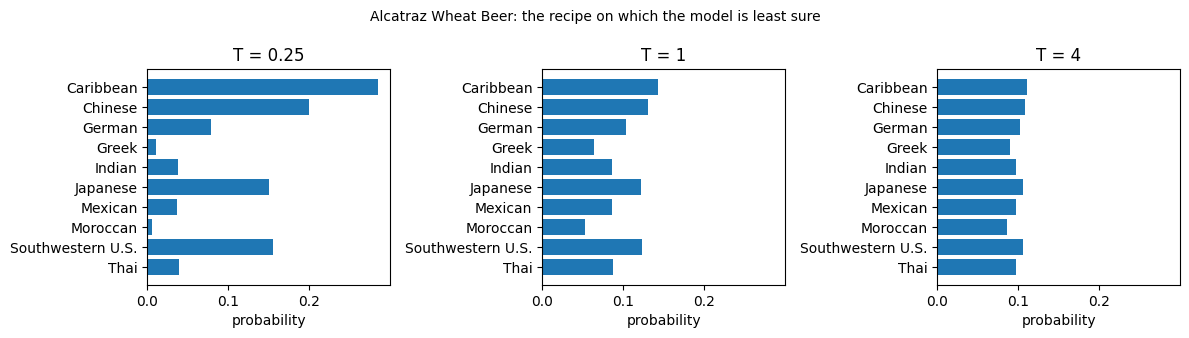

In [33]:
fig, ax = plt.subplots(ncols=3, figsize=(12, 3.4), sharex=True)
i = picked["least sure"]
for a, T in zip(ax, [0.25, 1, 4]):
    a.barh(classes, softmax(Z["linear"][i:i + 1] / T)[0])
    a.invert_yaxis()
    a.set_title(f"T = {T}")
    a.set_xlabel("probability")
plt.suptitle(html.unescape(recipes[indices[validation[i]]]["title"]) + ": the recipe on which the model is least sure", fontsize=10)
plt.tight_layout()

In [34]:
rows = {}
for T in [0.25, 0.5, 1, 2, 4]:
    P_T = softmax(Z["linear"] / T)
    rows[T] = {"greedy accuracy": (P_T.argmax(axis=1) == y_validation_multi).mean(),
               "sampling accuracy": (P_T * Y_validation).sum(axis=1).mean(),
               "perplexity": np.exp(cross_entropy(P_T, Y_validation))}

pd.DataFrame(rows).T.rename_axis("temperature").style.format({"greedy accuracy": "{:.1%}", "sampling accuracy": "{:.1%}", "perplexity": "{:.2f}"})

,greedy accuracy,sampling accuracy,perplexity
temperature,,,
0.250000,67.0%,66.1%,7.49
0.500000,67.0%,63.2%,3.28
1.000000,67.0%,54.0%,2.67
2.000000,67.0%,36.9%,3.35
4.000000,67.0%,22.1%,4.98


Reading the pictures: at $T = 4$ the distribution of the wheat beer is almost uniform, while at $T = 0.25$ it concentrates only a little, because the scores of this recipe are very close to each other, so even a low temperature has little to amplify. The ranking of the classes never changes.

In the table the **greedy accuracy is 67.0% for every temperature**: dividing the scores by a positive number does not change which one is the highest. The **sampling accuracy** goes from 66.1% (at $T = 0.25$ sampling is almost greedy) to 22.1% at $T = 4$, and it would tend to 10%, the accuracy of a random guess, for a very high temperature. And the **perplexity** is the lowest (2.67) for $T = 1$, the temperature for which the model was trained, and it increases in both directions: with $T < 1$ the model becomes overconfident and pays dearly for its errors (7.49 at $T = 0.25$), with $T > 1$ it becomes too cautious (4.98 at $T = 4$).

This is the example that we promised: the predictions are the same, the accuracy is the same, and the perplexity changes by almost a factor of three. The accuracy looks at the class that we choose, the perplexity at the distribution from which we choose it. The temperature is the same parameter that is used to control the randomness of the text generated by a large language model.

## Evaluation

### The problem with the accuracy

The first time that we computed the accuracy of the model that recognizes the Thai recipes, we found that it was 95.5%, and that a model that always answers `not Thai` has 90.5%. The accuracy counts the answers that are right, and for a rare class it is dominated by the class that is not rare. To say how good a model is at *finding* the Thai recipes we have to look separately at the two kinds of mistakes that it can make.

### The confusion matrix

For a binary problem there are four cases. We call the Thai recipes the **positive** class.

- **true positive** (TP): a Thai recipe that the model calls Thai;
- **false positive** (FP): a recipe that is not Thai, but the model calls it Thai;
- **false negative** (FN): a Thai recipe that the model calls `not Thai`;
- **true negative** (TN): a recipe that is not Thai and that the model calls `not Thai`.

The **confusion matrix** counts them: one row for each true class and one column for each predicted class.

In [35]:
from nlp.classification import confusion_matrix, precision_recall_f1, averages

predicted = (p_validation > 0.5).astype(int)
matrix = confusion_matrix(y_validation, predicted, n_classes=2)

pd.DataFrame(matrix, index=[f"true: {c}" for c in b_classes], columns=[f"predicted: {c}" for c in b_classes])

,predicted: not Thai,predicted: Thai
true: not Thai,964,4
true: Thai,44,58


Of the 1,070 recipes, 964 are correctly called `not Thai` and 58 are correctly called `Thai`. The model makes 48 mistakes, but of two very different kinds: only 4 recipes that are not Thai were called Thai (false positives), while 44 of the 102 Thai recipes were missed (false negatives). The accuracy counts the two kinds of mistakes together, 48 in all, and does not say that the model is missing almost half of what we are looking for.

### Precision, recall and F1

Two questions can be asked about the Thai recipes, and they have different answers.

- **Precision**: of the recipes that the model calls Thai, how many are really Thai? $\;\text{precision} = \dfrac{TP}{TP + FP}$
- **Recall**: of the Thai recipes, how many does the model find? $\;\text{recall} = \dfrac{TP}{TP + FN}$

A model that is very cautious, and says `Thai` only when it is certain, has a high precision and a low recall; a model that says `Thai` to everything has recall 1 and a very low precision. We want both, and we summarize them with the **F1 score**, the harmonic mean:

$$F_1 = \frac{2 \cdot \text{precision} \cdot \text{recall}}{\text{precision} + \text{recall}}$$

The harmonic mean is used and not the arithmetic one because it is close to the *lower* of the two values: a model cannot have a good F1 by being excellent on one and terrible on the other.

We compute the measures for the model, and for the two models that make no effort: the one that always says `not Thai` and the one that always says `Thai`.

In [36]:
def binary_report(predicted):
    matrix = confusion_matrix(y_validation, predicted, n_classes=2)
    precision, recall, f1 = precision_recall_f1(matrix)
    return {"accuracy": np.diag(matrix).sum() / matrix.sum(), "precision": precision[1], "recall": recall[1], "F1": f1[1]}

pd.DataFrame({
    "always `not Thai`": binary_report(np.zeros_like(y_validation)),
    "always `Thai`": binary_report(np.ones_like(y_validation)),
    "model": binary_report(predicted),
}).T.style.format("{:.1%}")

,accuracy,precision,recall,F1
always `not Thai`,90.5%,0.0%,0.0%,0.0%
always `Thai`,9.5%,9.5%,100.0%,17.4%
model,95.5%,93.5%,56.9%,70.7%


Look at the first two rows. The model that always says `not Thai` has an accuracy of 90.5% and it does not find any Thai recipe: recall and F1 are 0 (its precision is 0/0, because it never says `Thai`, and by convention we set it to 0). The one that always says `Thai` finds all of them (recall 100%), but it is right only when the recipe is Thai, that is 9.5% of the times, and its F1 is 17.4%. These two extremes are what precision and recall are made for: each one is easy to maximize alone, and the F1 punishes both.

The third row is the model. The accuracy of 95.5% was hiding what it does: it is a **cautious** model. When it says `Thai` it is almost always right (precision 93.5%), but it finds only 56.9% of the Thai recipes, and the F1 is 70.7%. The next cell checks that our functions give the same values as scikit-learn.

In [37]:
from sklearn.metrics import precision_recall_fscore_support

sk = precision_recall_fscore_support(y_validation, predicted, average="binary")[:3]
print("Same values with scikit-learn (precision, recall, F1):", np.round(sk, 4))

Same values with scikit-learn (precision, recall, F1): [0.9355 0.5686 0.7073]


### The threshold

The model gives a probability, and to obtain a class we chose the threshold 0.5. It is only a convention. If we lower it, the model calls Thai more recipes: it finds more of the Thai ones (higher recall) but also makes more mistakes among the others (lower precision). If we raise it, the opposite happens. This is the trade-off between the two measures, and the threshold is where we decide on which side we prefer to be wrong.

The best F1 on the validation set (76.5%) is obtained with a threshold of 0.20


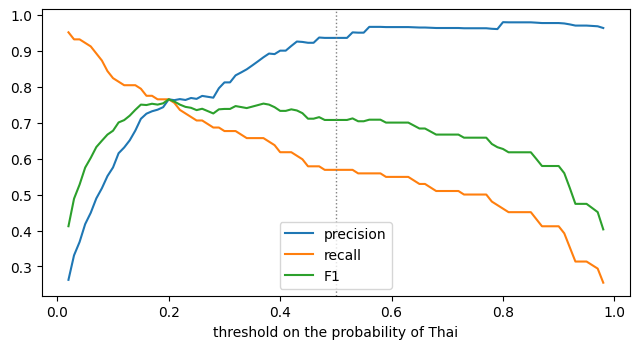

In [38]:
thresholds = np.linspace(0.02, 0.98, 97)
curve = np.array([[measure[1] for measure in precision_recall_f1(confusion_matrix(y_validation, (p_validation > t).astype(int), 2))]
                  for t in thresholds])   # for every threshold: precision, recall, F1 of the positive class

fig, ax = plt.subplots(figsize=(6.5, 3.6))
for j, name in enumerate(["precision", "recall", "F1"]):
    ax.plot(thresholds, curve[:, j], label=name)
ax.axvline(0.5, color="gray", linestyle=":", linewidth=1)
ax.set_xlabel("threshold on the probability of Thai")
ax.legend()
plt.tight_layout()

best = thresholds[curve[:, 2].argmax()]
print(f"The best F1 on the validation set ({curve[:, 2].max():.1%}) is obtained with a threshold of {best:.2f}")

The curves show the trade-off. As the threshold grows, the precision goes up (the model says `Thai` only when it is very sure) and the recall goes down. At 0.5 the precision is 93.5% and the recall 56.9%; the F1 is the highest for a threshold of 0.20, where the two measures are both close to 76%. At that point the model finds more Thai recipes (higher recall) and accepts more false positives.

Which threshold is the best depends on what the model is used for: to suggest Thai recipes to somebody who likes them we may prefer to miss few (a low threshold), and to label a catalog of recipes we may prefer to make few mistakes (a high one). A choice like this is made on the validation set, and never on the test set, that must not influence any decision.

### Many classes

With ten cuisines the confusion matrix has ten rows and ten columns. The diagonal contains the recipes that are classified correctly, and every other cell says *which* mistake was made: how many recipes of the true class in the row were assigned to the class in the column. We build it for the model without hidden layers, on the validation set. To read it better, we color the cells by the share of the row (the proportion of the recipes of that cuisine).

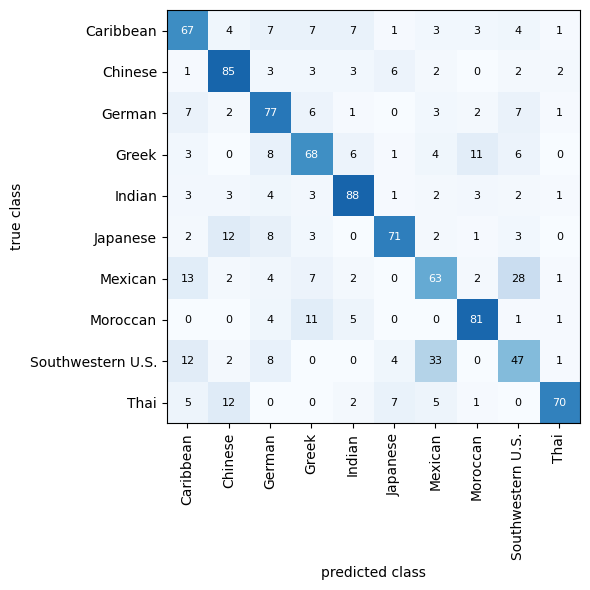

In [39]:
def plot_confusion(matrix, classes, ax):
    share = matrix / matrix.sum(axis=1, keepdims=True)
    ax.imshow(share, cmap="Blues", vmin=0, vmax=1)
    for i in range(len(classes)):
        for j in range(len(classes)):
            ax.text(j, i, matrix[i, j], ha="center", va="center", fontsize=8,
                    color="white" if share[i, j] > 0.5 else "black")
    ax.set_xticks(range(len(classes)), classes, rotation=90)
    ax.set_yticks(range(len(classes)), classes)
    ax.set_xlabel("predicted class")
    ax.set_ylabel("true class")

matrix = confusion_matrix(y_validation_multi, P_validation.argmax(axis=1), n_classes=len(classes))

fig, ax = plt.subplots(figsize=(7, 6))
plot_confusion(matrix, classes, ax)
plt.tight_layout()

The diagonal is dominant: the model classifies correctly most of the recipes of every cuisine (88 of 110 Indian recipes, 85 of 107 Chinese, 81 of 103 Moroccan). What we learn from the matrix is in the cells out of the diagonal, because the errors are not random.

- The largest confusion is between `Mexican` and `Southwestern U.S.`: 28 Mexican recipes are assigned to `Southwestern U.S.` and 33 recipes of `Southwestern U.S.` to `Mexican`, and only 47 of the 107 recipes of the latter are classified correctly.
- `Japanese` and `Thai` recipes are confused with `Chinese` ones (12 each), and `Greek` and `Moroccan` recipes with one another (11 in both directions).
- `Caribbean` collects the errors of `Mexican` (13) and of `Southwestern U.S.` (12).

They are the cuisines that share ingredients, or that are geographically close, and the mistakes of the model are the ones that we would make ourselves. The accuracy cannot tell any of it.

### Precision and recall of every class

For each class we treat the problem as a binary one (that class against all the others) and we compute precision and recall from the matrix. The recall of a class is the diagonal cell divided by the sum of its **row**: of the recipes of that cuisine, how many the model finds. The precision is the diagonal cell divided by the sum of its **column**: of the recipes that the model assigns to that cuisine, how many are really of that cuisine. The support is the number of recipes of the class.

In [40]:
def per_class(matrix, classes):
    precision, recall, f1 = precision_recall_f1(matrix)
    return pd.DataFrame({"precision": precision, "recall": recall, "F1": f1, "support": matrix.sum(axis=1)}, index=classes)

report = per_class(matrix, classes)
report.style.format({"precision": "{:.1%}", "recall": "{:.1%}", "F1": "{:.1%}", "support": "{:.0f}"}
                    ).background_gradient(subset=["F1"], cmap="Blues", vmin=0.3, vmax=1)

,precision,recall,F1,support
Caribbean,59.3%,64.4%,61.8%,104
Chinese,69.7%,79.4%,74.2%,107
German,62.6%,72.6%,67.2%,106
Greek,63.0%,63.6%,63.3%,107
Indian,77.2%,80.0%,78.6%,110
Japanese,78.0%,69.6%,73.6%,102
Mexican,53.8%,51.6%,52.7%,122
Moroccan,77.9%,78.6%,78.3%,103
Southwestern U.S.,47.0%,43.9%,45.4%,107
Thai,89.7%,68.6%,77.8%,102


The F1 goes from 78.6% (`Indian`), 78.3% (`Moroccan`) and 77.8% (`Thai`) to 52.7% for `Mexican` and 45.4% for `Southwestern U.S.`, the two cuisines of the largest confusion: for these classes both precision and recall are low.

The numbers also show the *character* of the errors of each class. `Thai` has a precision of 89.7% and a recall of 68.6%, so it is a class that the model assigns with caution (the same as in the binary model, that had 93.5% and 56.9%). `Chinese` has the opposite profile (recall 79.4%, precision 69.7%), because it is a class that receives the mistakes of `Japanese` and `Thai`. Note also that the recall of `Thai` is here higher than in the binary problem: with ten classes a recipe is assigned to `Thai` if that class has the *highest* probability, and not if it has more than 0.5, so the decision is less demanding and finds more of the Thai recipes, at the price of some precision.

### One number for all the classes

To compare two models it is convenient to have a single number, and there are three ways of averaging the measures of the classes.

- The **macro** average is the mean of the values of the classes: every class counts the same, whatever its size.
- The **weighted** average is the mean weighted by the support: every *recipe* counts the same, and a large class weighs more.
- The **micro** average pools the counts of all the classes (the sum of the diagonal over the total). In a problem in which each recipe has exactly one class, precision, recall and F1 micro are all equal to the accuracy.

The macro average is the one to watch when the classes are unbalanced: a model that is very good on the large classes and useless on the small ones has a good micro and weighted value, and a poor macro value. We compute the three averages for the ten cuisines, and also for the binary problem, in which the positive class is rare.

In [41]:
def averages_table(matrix):
    return pd.DataFrame(averages(matrix)).T.rename(columns={"f1": "F1"})

pd.concat({"ten cuisines": averages_table(matrix),
           "Thai / not Thai": averages_table(confusion_matrix(y_validation, predicted, 2))}
          ).style.format("{:.1%}")

For the ten cuisines the three averages are practically the same (F1 of 67.0%, 67.3% and 67.0%): the classes have between 102 and 122 recipes, so giving the same weight to each class or to each recipe makes no difference.

In the binary problem they are not the same. The micro average is 95.5% (it is the accuracy, and it inherits its problem), the weighted one is 95.0%, and the macro F1 is **84.2%**: the average gives the same weight to the two classes, and the Thai recipes, that are only 9.5% of the total, are the ones on which the model is weak (recall of 56.9%). This is the reason why, when the classes are unbalanced, we report the macro average or the values of the single classes, and in any case we say which average we are using.

## Comparing the two models

### The protocol

We have two models and we want to say which one is better, and *in what*. A comparison is fair if the two models are treated in the same way, so we fix the protocol before looking at any result.

1. **The hyper-parameters are chosen on the validation set.** For each model we try a few learning rates, and for each one we stop the training at the epoch with the lowest validation loss. We keep the learning rate with the lowest validation loss.
2. **The training is random for the network with the hidden layer**: the initial weights and the order of the mini-batches depend on a seed. We train it with five different seeds. The model without hidden layers is deterministic: it starts from zero and uses the whole training set at each step.
3. **The test set is used once**, at the end, with the models that we have chosen, and nothing is changed after having seen the result.

In [42]:
def fit_linear(learning_rate, epochs=3000):
    _, _, history = train_softmax(X_train, Y_train, X_validation, Y_validation, learning_rate, epochs)
    best = history[:, 1].argmin() + 1
    W, b, _ = train_softmax(X_train, Y_train, X_validation, Y_validation, learning_rate, best)
    return (W, b), best, history[best - 1, 1]

def fit_hidden(learning_rate, seed=0, epochs=300, units=64):
    torch.manual_seed(seed)
    model = nn.Sequential(nn.Linear(X_train.shape[1], units), nn.ReLU(), nn.Linear(units, len(classes)))
    history, best = train_network(model, learning_rate, epochs, seed=seed)
    return model, best, history[best - 1, 1]

grid = {}
for learning_rate in [1, 3, 10, 30]:
    _, best, validation_loss = fit_linear(learning_rate)
    grid[("linear", learning_rate)] = {"best epoch": best, "validation loss": validation_loss}
for learning_rate in [1e-4, 3e-4, 1e-3]:
    _, best, validation_loss = fit_hidden(learning_rate)
    grid[("hidden layer", learning_rate)] = {"best epoch": best, "validation loss": validation_loss}

grid = pd.DataFrame(grid).T.rename_axis(["model", "learning rate"])
grid.style.format({"best epoch": "{:.0f}", "validation loss": "{:.3f}"})

For the model without hidden layers a learning rate of 1 is too small (the validation loss is still going down after 3,000 epochs), and 30 is too large, so the training does not settle (1.082); 3 and 10 reach the same value (0.981), 10 in fewer epochs. For the network with the hidden layer the three learning rates arrive at the same validation loss (0.953), and what changes is the number of epochs that they need: a smaller learning rate takes more steps to get to the same place. In both cases the choice of the learning rate, once it is in a reasonable range, has little influence on the result.

In [43]:
best_lr = {model: grid.loc[model]["validation loss"].idxmin() for model in ["linear", "hidden layer"]}
print("Chosen learning rates:", best_lr)

(W_final, b_final), _, _ = fit_linear(best_lr["linear"])
hidden_models = [fit_hidden(best_lr["hidden layer"], seed=seed)[0] for seed in range(5)]

def distribution_linear(x):
    return softmax(x @ W_final + b_final)

def distribution_hidden(x, model=None):
    with torch.no_grad():
        return torch.softmax((model or hidden_models[0])(to_tensor(x) if not torch.is_tensor(x) else x), dim=1).numpy()

Chosen learning rates: {'linear': 10.0, 'hidden layer': 0.0001}


### The test set, for the first time

The models are fixed. For the network with the hidden layer we take, as *the* model, the one trained with the first seed, and we keep the other four to see how much the result depends on the seed. We compute the measures on the test set, for the ten cuisines.

In [44]:
y_test_multi = labels[test]
Y_test_onehot = np.eye(len(classes))[y_test_multi]
K = len(classes)

P_test = {"linear": distribution_linear(X_test), "hidden layer": distribution_hidden(x_test)}
test_matrix = {name: confusion_matrix(y_test_multi, P.argmax(axis=1), K) for name, P in P_test.items()}

def summary(P, y=y_test_multi):
    m = confusion_matrix(y, P.argmax(axis=1), K)
    precision, recall, f1 = precision_recall_f1(m)
    return {"accuracy": np.diag(m).sum() / m.sum(), "macro precision": precision.mean(), "macro recall": recall.mean(),
            "macro F1": f1.mean(), "perplexity": np.exp(cross_entropy(P, np.eye(K)[y]))}

pd.DataFrame({name: summary(P) for name, P in P_test.items()}).T.style.format(
    {"accuracy": "{:.1%}", "macro precision": "{:.1%}", "macro recall": "{:.1%}", "macro F1": "{:.1%}", "perplexity": "{:.2f}"})

,accuracy,macro precision,macro recall,macro F1,perplexity
linear,68.7%,69.2%,69.0%,69.0%,2.56
hidden layer,68.7%,68.8%,68.9%,68.8%,2.45


The two models have the same accuracy on the test set (68.7%), almost the same macro F1 (69.0% and 68.8%), and a different perplexity: 2.56 for the model without hidden layers and 2.45 for the network. The hidden layer does not improve the decisions that the model takes, but the probabilities seem better.

Note that the accuracy on the test set (68.7%) is more than a point higher than the one on the validation set (67.0%), for the same model. Nothing has changed except the 1,070 recipes on which it was computed: it gives an idea of how much a number of this kind moves because of the sample.

### Is the difference real?

A difference between two numbers computed on a sample of 1,070 recipes can be due to the sample. There are two sources of variation, and we look at both.

The first one is **the training**: another seed gives another network. We evaluate on the test set the five networks, and we compare their range with the value of the model without hidden layers.

In [45]:
seeds = pd.DataFrame([summary(distribution_hidden(x_test, model)) for model in hidden_models]).rename_axis("seed")
seeds.loc["linear"] = summary(P_test["linear"])

pd.concat([seeds.iloc[:5], seeds.iloc[:5].agg(["mean", "std"]), seeds.iloc[[5]]]).style.format(
    {"accuracy": "{:.1%}", "macro precision": "{:.1%}", "macro recall": "{:.1%}", "macro F1": "{:.1%}", "perplexity": "{:.3f}"})

,accuracy,macro precision,macro recall,macro F1,perplexity
0,68.7%,68.8%,68.9%,68.8%,2.448
1,68.4%,68.6%,68.7%,68.5%,2.433
2,68.6%,68.9%,68.9%,68.8%,2.432
3,68.9%,69.1%,69.1%,69.0%,2.435
4,68.3%,68.4%,68.6%,68.4%,2.438
mean,68.6%,68.7%,68.8%,68.7%,2.437
std,0.2%,0.2%,0.2%,0.2%,0.007
linear,68.7%,69.2%,69.0%,69.0%,2.558


The five networks have an accuracy between 68.3% and 68.9% (standard deviation of 0.2 points), and the model without hidden layers, with 68.7%, is inside the range: with these data the difference in accuracy or in F1 between the two models is smaller than the difference between two seeds. The perplexity is a different story: the five networks have between 2.432 and 2.448, always below the 2.558 of the linear model. The training is not the reason of that difference.

The second one is **the test set**: with other 1,070 recipes the result would be different. We estimate it with the **bootstrap**: we draw recipes of the test set *with replacement*, until we have another set of the same size, and we compute again the difference between the two models on the same recipes, for 1,000 different samples. The interval that contains 95% of the differences tells us how much the difference depends on the recipes that we happened to have.

In [46]:
rng = np.random.default_rng(0)
n_test = len(y_test_multi)
pred_linear, pred_hidden = P_test["linear"].argmax(axis=1), P_test["hidden layer"].argmax(axis=1)
surprisal_linear = -np.log((P_test["linear"] * Y_test_onehot).sum(axis=1))
surprisal_hidden = -np.log((P_test["hidden layer"] * Y_test_onehot).sum(axis=1))

def macro_f1(y, pred):
    return precision_recall_f1(confusion_matrix(y, pred, K))[2].mean()

boot = []
for _ in range(1000):
    s = rng.integers(0, n_test, n_test)
    boot.append((np.mean(pred_hidden[s] == y_test_multi[s]) - np.mean(pred_linear[s] == y_test_multi[s]),
                 macro_f1(y_test_multi[s], pred_hidden[s]) - macro_f1(y_test_multi[s], pred_linear[s]),
                 np.exp(surprisal_hidden[s].mean()) - np.exp(surprisal_linear[s].mean())))
boot = np.array(boot)

pd.DataFrame({"difference (hidden layer - linear)": [np.mean(pred_hidden == y_test_multi) - np.mean(pred_linear == y_test_multi),
                                                       macro_f1(y_test_multi, pred_hidden) - macro_f1(y_test_multi, pred_linear),
                                                       np.exp(surprisal_hidden.mean()) - np.exp(surprisal_linear.mean())],
              "95% interval, lower": np.percentile(boot, 2.5, axis=0),
              "95% interval, upper": np.percentile(boot, 97.5, axis=0)},
             index=["accuracy", "macro F1", "perplexity"]).style.format("{:+.3f}")

,difference (hidden layer - linear),"95% interval, lower","95% interval, upper"
accuracy,+0.000,-0.015,+0.015
macro F1,-0.003,-0.017,+0.012
perplexity,-0.110,-0.160,-0.061


The difference in accuracy is 0.0 points, with an interval that goes from $-1.5$ to $+1.5$, and the one in macro F1 is $-0.3$, between $-1.7$ and $+1.2$: both intervals contain zero. We have no evidence that one of the models classifies better than the other, and the width of the intervals (about three points) tells us the resolution of this test set: a difference smaller than that cannot be seen with 1,070 recipes.

The difference in perplexity, $-0.11$, has an interval from $-0.16$ to $-0.06$ that does *not* contain zero: the probabilities of the network with the hidden layer are better, in a way that is not explained by the choice of the test recipes. (The bootstrap measures the variation due to the test set. The variation due to the training is the one of the previous table.)

### Where do the models differ?

The averages say that the two models are similar. The next question is whether they are similar *in the same way*: the same accuracy can come from models that make different mistakes. We look at three things: the cuisines, the recipes, and the confusions.

**The cuisines.** The F1 of each cuisine, on the test set, for the two models.

In [47]:
f1_test = pd.DataFrame({name: precision_recall_f1(m)[2] for name, m in test_matrix.items()}, index=classes)
f1_test["difference"] = f1_test["hidden layer"] - f1_test["linear"]

f1_test.style.format("{:.1%}").format({"difference": "{:+.1%}"}).background_gradient(
    subset=["difference"], cmap="RdBu", vmin=-0.1, vmax=0.1)

,linear,hidden layer,difference
Caribbean,0.572816,0.593301,+2.0%
Chinese,0.753488,0.759259,+0.6%
German,0.723214,0.711712,-1.2%
Greek,0.727273,0.735849,+0.9%
Indian,0.822430,0.818182,-0.4%
Japanese,0.773196,0.773196,+0.0%
Mexican,0.556452,0.568093,+1.2%
Moroccan,0.765550,0.746411,-1.9%
Southwestern U.S.,0.422018,0.393939,-2.8%
Thai,0.788177,0.778325,-1.0%


The differences go from $-2.8$ to $+2.0$ points, with both signs, and there is no cuisine in which the hidden layer wins clearly. Each cuisine has about 100 recipes in the test set, so a change of two points is a handful of recipes. The largest movements are for `Southwestern U.S.` ($-2.8$, from 42.2% to 39.4%) and `Caribbean` ($+2.0$), and the easiest and the hardest cuisines are the same for both models: `Indian`, `Thai` and `Japanese` at the top, `Mexican` and `Southwestern U.S.` at the bottom.

**The recipes.** For each recipe of the test set we look at whether each model is right or wrong.

In [48]:
from scipy.stats import binomtest

right_linear, right_hidden = pred_linear == y_test_multi, pred_hidden == y_test_multi
agreement = pd.DataFrame({"hidden layer right": [(right_linear & right_hidden).sum(), (~right_linear & right_hidden).sum()],
                          "hidden layer wrong": [(right_linear & ~right_hidden).sum(), (~right_linear & ~right_hidden).sum()]},
                         index=["linear right", "linear wrong"])
display(agreement)

only_linear, only_hidden = (right_linear & ~right_hidden).sum(), (~right_linear & right_hidden).sum()
print(f"The two models give the same answer on {np.mean(pred_linear == pred_hidden):.1%} of the recipes")
print(f"Recipes on which only one of them is right: {only_linear} (linear), {only_hidden} (hidden layer);",
      f"p-value of the exact test of McNemar: {binomtest(only_linear, only_linear + only_hidden, 0.5).pvalue:.2f}")

,hidden layer right,hidden layer wrong
linear right,702,33
linear wrong,33,302


The two models give the same answer on 90.3% of the recipes
Recipes on which only one of them is right: 33 (linear), 33 (hidden layer); p-value of the exact test of McNemar: 1.00


The two models give the same answer on 90.3% of the recipes, and on the other 104 they answer differently. On 67 of these exactly one of the two is right, and it is 33 recipes for each model: they compensate each other exactly, and the test of McNemar (that looks only at the recipes on which the models disagree) has a p-value of 1.00. Two models with the same accuracy are not necessarily the same model, but here the differences do not favor either.

Look also at the last cell of the table: 302 recipes (28% of the test set) are wrong for **both** models. The errors are largely shared: they are recipes that these ingredients do not allow to classify, and changing the model does not change them. This is a first useful piece of information for the analysis of the results: the limit seems to be in the *information* that we give to the models (the ingredients) more than in the model.

**The confusions.** Which cells of the confusion matrix change more from one model to the other? We list the five errors that become *less* frequent with the hidden layer, and the five that become *more* frequent.

In [49]:
difference = test_matrix["hidden layer"] - test_matrix["linear"]
changes = pd.DataFrame([(classes[i], classes[j], test_matrix["linear"][i, j], test_matrix["hidden layer"][i, j], difference[i, j])
                        for i in range(K) for j in range(K) if i != j],
                       columns=["true class", "assigned to", "linear", "hidden layer", "change"])

pd.concat({"fewer with the hidden layer": changes.nsmallest(5, "change"),
           "more with the hidden layer": changes.nlargest(5, "change")}).droplevel(1).style.format({"change": "{:+.0f}"})

,true class,assigned to,linear,hidden layer,change
fewer with the hidden layer,Mexican,Southwestern U.S.,37,31,-6
fewer with the hidden layer,Caribbean,Southwestern U.S.,14,9,-5
fewer with the hidden layer,Indian,Southwestern U.S.,5,0,-5
fewer with the hidden layer,Southwestern U.S.,Caribbean,11,8,-3
fewer with the hidden layer,Caribbean,Mexican,5,3,-2
more with the hidden layer,Southwestern U.S.,Mexican,38,46,+8
more with the hidden layer,German,Southwestern U.S.,2,6,+4
more with the hidden layer,Mexican,Caribbean,5,8,+3
more with the hidden layer,Caribbean,Greek,2,4,+2
more with the hidden layer,Caribbean,Indian,1,3,+2


The changes are small (a handful of recipes for each cell) and we should not read too much in them. The largest one is on the pair that we already know: with the hidden layer `Mexican` recipes assigned to `Southwestern U.S.` go from 37 to 31, but `Southwestern U.S.` recipes assigned to `Mexican` go from 38 to 46. The network has moved the boundary between the two cuisines rather than separating them better, and this explains the lower F1 of `Southwestern U.S.`. The other changes are errors towards `Southwestern U.S.` that decrease (`Caribbean`, 14 to 9; `Indian`, 5 to 0) or increase (`German`, 2 to 6).

### Where does the difference in perplexity come from?

The accuracy and the F1 are the same, but the perplexity of the network with the hidden layer is lower. We separate the recipes on which the models are right from the ones on which they are wrong, and we look at the surprisal (the negative logarithm of the probability of the true class) and at the confidence (the probability that the model gives to its answer).

In [50]:
rows = {}
for name, P in P_test.items():
    right = P.argmax(axis=1) == y_test_multi
    surprisal = -np.log((P * Y_test_onehot).sum(axis=1))
    confidence = P.max(axis=1)
    rows[name] = {"confidence, when right": confidence[right].mean(), "confidence, when wrong": confidence[~right].mean(),
                  "surprisal, when right": surprisal[right].mean(), "surprisal, when wrong": surprisal[~right].mean()}

display(pd.DataFrame(rows).T.style.format("{:.3f}"))

def top_k_accuracy(P, k):
    rank = (P > P[np.arange(len(P)), y_test_multi][:, None]).sum(axis=1)   # how many classes are ranked above the true one
    return (rank < k).mean()

pd.DataFrame({name: {f"true class in the top {k}": top_k_accuracy(P, k) for k in [1, 2, 3]} for name, P in P_test.items()}
             ).T.style.format("{:.1%}")

,"confidence, when right","confidence, when wrong","surprisal, when right","surprisal, when wrong"
linear,0.734,0.495,0.362,2.205
hidden layer,0.747,0.494,0.341,2.110


,true class in the top 1,true class in the top 2,true class in the top 3
linear,68.7%,84.7%,90.1%
hidden layer,68.7%,85.6%,91.4%


The confidence of the two models is the same, both when they are right (73.4% and 74.7%) and when they are wrong (49.5% and 49.4%). The difference is in the surprisal: it is a bit lower with the hidden layer when the model is right (0.341 against 0.362) and, above all, when it is wrong (2.11 against 2.21). As the models are wrong on 31% of the recipes, about two thirds of the difference in cross-entropy comes from the wrong answers: when the hidden layer makes a mistake, it gives on average more probability to the true class.

The last table confirms it. The first choice is right in the same proportion (68.7%), but the true class is more often among the first two (85.6% against 84.7%) or three (91.4% against 90.1%) choices of the hidden layer. The differences are of about one point, and we have not tested them, but they go in the direction of the perplexity: the network *ranks* the cuisines a little better after the first one, and this is what the accuracy cannot see and the perplexity can.

### What we can say about the two models

With the ingredients of 3,209 recipes and ten cuisines:

- **The decisions are equivalent.** Accuracy and macro F1 are the same, the differences by cuisine have both signs, and where the two models disagree they are right the same number of times.
- **The probabilities are a bit better with the hidden layer.** The perplexity is lower (2.45 against 2.56) with an interval that excludes zero, and the gain comes mostly from the recipes on which the model is wrong, in which the true class is more often the second or the third choice.
- **The two models make the same mistakes.** 28% of the recipes are wrong for both, and the hard pair is `Mexican` and `Southwestern U.S.`: the network moves the boundary between them, but does not make it disappear.

The dense representation of the hidden layer is a richer description of the recipes, as we saw in the previous section, but it is not a richer *information*: it is built from the same ingredients, and it cannot recognize what those ingredients do not tell. To understand better what limits the models, we now change the task.

## A different task: the type of dish

The same recipes have a second label: the **type** of dish (`Beverages`, `Bread`, `Breakfast`, `Dessert`, `Lunch/Snacks`, `One Dish Meal`, `Soup/Stew`, `Vegetable`). It is a good occasion to use what we built. We change the `LabelScheme` and we repeat *the same protocol*, with the same input (the ingredients), the same two models, the same measures, and we use the evaluation to understand how the two problems differ.

To apply the protocol to another problem we do not want to copy the code of the previous sections. The functions that we wrote (the training of the model without hidden layers and of the network, the choice of the learning rate, the seeds) are collected in a module, `nlp.experiments`, that works on a **task**: the recipes with a label, the split, and the TF-IDF vectors computed on the training set. We build the task for the cuisine, and we check that we obtain the same split of the previous sections; then we build the one for the type.

In [51]:
from nlp.experiments import prepare_task, compare_models
from nlp.classification import summarize

tasks = {"cuisine": prepare_task(recipes, terms, LabelScheme("cuisine")),
         "type": prepare_task(recipes, terms, LabelScheme("type"))}

print("Same split as before for the cuisine:", np.array_equal(tasks["cuisine"].test, test))

rows = {}
for name, task in tasks.items():
    counts = np.bincount(task.labels)
    prior_train = np.bincount(task.y(task.train), minlength=len(task.classes)) / len(task.train)
    y_test_task = task.y(task.test)
    rows[name] = {"recipes with a label": len(task.labels), "classes": len(task.classes),
                  "smallest class": counts.min(), "largest class": counts.max(), "terms in the vocabulary": len(task.vocabulary),
                  "accuracy of the largest class": np.mean(y_test_task == prior_train.argmax()),
                  "perplexity of the prior": summarize(np.tile(prior_train, (len(y_test_task), 1)), y_test_task)["perplexity"]}

pd.DataFrame(rows).T.style.format({"recipes with a label": "{:,.0f}", "classes": "{:.0f}", "smallest class": "{:.0f}", "largest class": "{:.0f}",
                                    "terms in the vocabulary": "{:.0f}", "accuracy of the largest class": "{:.1%}", "perplexity of the prior": "{:.2f}"})

Same split as before for the cuisine: True


,recipes with a label,classes,smallest class,largest class,terms in the vocabulary,accuracy of the largest class,perplexity of the prior
cuisine,"5,349",10,508,612,768,11.5%,9.99
type,"7,060",8,745,1084,870,15.3%,7.91


The two tasks are of similar size, but they are not the same problem. The type of dish has more recipes with a label (7,060 against 5,349), fewer classes (8 against 10), classes that are a bit less balanced (from 745 to 1,084 recipes, with the largest class at 15.3%, against 11.5%), and a vocabulary that is a little larger (870 terms against 768). The last column is the reference that we will use to read the perplexities: the model that answers with the proportions of the classes, without looking at the recipe, has a perplexity of 9.99 for the cuisine and of 7.91 for the type.

In [52]:
comparison = {"cuisine": None, "type": compare_models(tasks["type"])}
print("Chosen learning rates for the type:", comparison["type"].chosen)
comparison["type"].grid.style.format({"best epoch": "{:.0f}", "validation loss": "{:.3f}"})

Chosen learning rates for the type: {'linear': 10.0, 'hidden layer': 0.0001}


### The same evaluation

We compute the measures on the test set of the type of dish, and we put them next to the ones of the cuisine that we already have. The last column is the perplexity of the model that answers with the proportion of the classes: it is the reference, because the number of classes is different (ten and eight) and the perplexities cannot be compared directly.

In [53]:
results = {"cuisine": {"linear": P_test["linear"], "hidden layer": P_test["hidden layer"]},
           "type": comparison["type"].P_test}
y_tests = {"cuisine": tasks["cuisine"].y(tasks["cuisine"].test), "type": tasks["type"].y(tasks["type"].test)}

table = pd.DataFrame({(name, model): {**summarize(P, y_tests[name]), "prior perplexity": rows[name]["perplexity of the prior"]}
                      for name, models in results.items() for model, P in models.items()}).T
table.rename_axis(["task", "model"]).style.format({"accuracy": "{:.1%}", "macro precision": "{:.1%}", "macro recall": "{:.1%}",
                                                    "macro F1": "{:.1%}", "perplexity": "{:.2f}", "prior perplexity": "{:.2f}"})

With the ingredients alone, the type of dish is a **harder** problem than the cuisine: the accuracy is 59.4% against 68.7%, and the macro F1 60.2% against 69.0%, even if it has fewer classes and a higher baseline. The perplexities cannot be compared directly, because the number of classes is not the same, but we can compare them with the reference: the perplexity of the models is 26% of the one of the prior for the cuisine (2.56 over 9.99) and 38% for the type (2.97 over 7.91). The ingredients take away less of the uncertainty about the type.

The comparison between the two models gives the same picture as for the cuisine: same decisions (58.8% and 59.4% of accuracy), and a slightly lower perplexity with the hidden layer.

In [54]:
def paired_bootstrap(P_a, P_b, y, repetitions=1000, seed=0):
    rng = np.random.default_rng(seed)
    measures = ["accuracy", "macro F1", "perplexity"]

    def difference(sample):
        a, b = summarize(P_a[sample], y[sample]), summarize(P_b[sample], y[sample])
        return [b[m] - a[m] for m in measures]

    observed = difference(np.arange(len(y)))
    boot = np.array([difference(rng.integers(0, len(y), len(y))) for _ in range(repetitions)])
    return pd.DataFrame({"difference": observed, "95% interval, lower": np.percentile(boot, 2.5, axis=0),
                         "95% interval, upper": np.percentile(boot, 97.5, axis=0)}, index=measures)

pd.concat({name: paired_bootstrap(models["linear"], models["hidden layer"], y_tests[name]) for name, models in results.items()}
          ).style.format("{:+.3f}")

The pattern of the cuisine is confirmed. The differences in accuracy ($-0.6$ points, interval from $-2.1$ to $+0.8$) and in macro F1 ($-0.5$, from $-2.1$ to $+1.1$) are compatible with zero, and the perplexity is lower with the hidden layer ($-0.05$, from $-0.10$ to $-0.01$). But the effect on the probabilities is smaller than for the cuisine ($-0.11$) and the interval is very close to zero: on this task the hidden layer gives even less. Two problems and two models give the same conclusion: the hidden layer does not change the decisions, and it improves a little the probabilities.

### The confusion matrix of the type

As for the cuisine, we look at where the model is wrong. The matrix is the one of the model without hidden layers, on the test set.

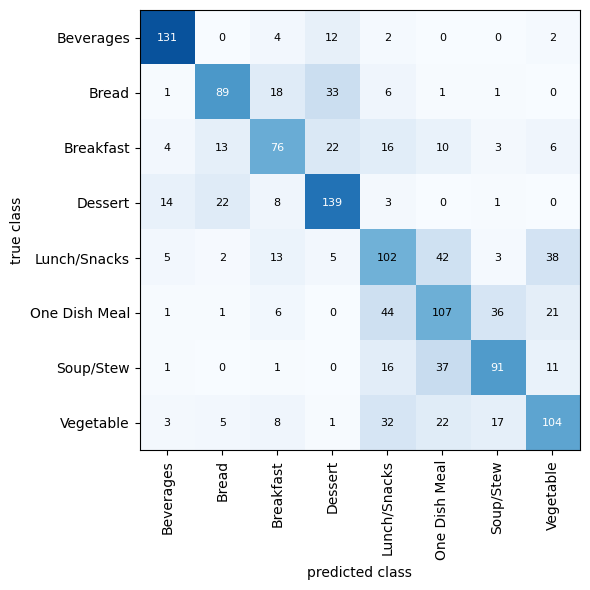

In [55]:
type_task = tasks["type"]
type_matrix = confusion_matrix(y_tests["type"], results["type"]["linear"].argmax(axis=1), len(type_task.classes))

fig, ax = plt.subplots(figsize=(7, 6))
plot_confusion(type_matrix, type_task.classes, ax)
plt.tight_layout()

The matrix has a **block structure**. There are two groups of classes, one of drinks, baked goods and sweets (`Beverages`, `Bread`, `Breakfast`, `Dessert`) and one of savory dishes (`Lunch/Snacks`, `One Dish Meal`, `Soup/Stew`, `Vegetable`), and almost all the mistakes are *inside* a group.

- Among the first ones, `Bread` and `Dessert` are confused with one another (33 and 22 recipes), and `Breakfast` is often assigned to `Dessert` (22).
- Among the savory dishes: `Lunch/Snacks` goes to `One Dish Meal` (42) and to `Vegetable` (38), `One Dish Meal` to `Lunch/Snacks` (44) and to `Soup/Stew` (36), and `Soup/Stew` to `One Dish Meal` (37).

Compare it with the matrix of the cuisine. There the confusions were between neighbor *traditions*. Here they are between categories that are **not mutually exclusive**: a soup can be a one-dish meal, a sweet bread can be a dessert or a breakfast. The type says what *role* the dish has in a meal, and the same dish may have more than one.

In [56]:
f1_type = pd.DataFrame({model: precision_recall_f1(confusion_matrix(y_tests["type"], P.argmax(axis=1), len(type_task.classes)))[2]
                        for model, P in results["type"].items()}, index=type_task.classes)
f1_type["support"] = type_matrix.sum(axis=1)
f1_type.sort_values("linear", ascending=False).style.format({"linear": "{:.1%}", "hidden layer": "{:.1%}", "support": "{:.0f}"})

,linear,hidden layer,support
Beverages,84.2%,84.1%,151
Dessert,69.7%,68.1%,187
Bread,63.3%,63.2%,149
Soup/Stew,58.9%,59.1%,157
Vegetable,55.6%,55.8%,192
Breakfast,53.5%,51.2%,150
One Dish Meal,49.2%,48.7%,216
Lunch/Snacks,47.3%,47.3%,210


The F1 goes from 84.2% for `Beverages` and 69.7% for `Dessert` to 49.2% for `One Dish Meal` and 47.3% for `Lunch/Snacks`. The best are the categories defined by their *content* (a drink, a sweet), the worst are the ones defined by their *role* or, in a sense, by exclusion. The two models differ by less than two and a half points in every class.

### Reading the errors

The numbers say how many mistakes there are, but not what kind of mistakes. We read them: for each task, the recipes of the test set on which the model (without hidden layers) is *wrong and most confident*.

In [57]:
def confident_errors(P, task, k=8):
    y = task.y(task.test)
    wrong = np.where(P.argmax(axis=1) != y)[0]
    picked = wrong[np.argsort(-P[wrong].max(axis=1))][:k]
    return pd.DataFrame([{"recipe": html.unescape(recipes[task.indices[task.test[i]]]["title"])[:34],
                          "ingredients": ", ".join(recipes[task.indices[task.test[i]]]["ingredients"])[:70] + "...",
                          "true": task.classes[y[i]], "predicted": task.classes[P[i].argmax()],
                          "P(predicted)": P[i].max(), "P(true)": P[i, y[i]]} for i in picked])

pd.set_option("display.max_colwidth", 80)
for name, task in tasks.items():
    print(name)
    display(confident_errors(results[name]["linear"], task).style.format({"P(predicted)": "{:.2f}", "P(true)": "{:.3f}"}).hide(axis="index"))

cuisine


recipe,ingredients,true,predicted,P(predicted),P(true)
Cheese Enchiladas in Red Chile Gra,"cumin, ancho chilies, garlic, serrano chili, Mexican oregano, chicken ...",Southwestern U.S.,Mexican,0.99,0.013
Chicken Lettuce Wraps,"iceberg lettuce, romaine lettuce leaf, soy sauce, oyster sauce, dry sh...",Thai,Chinese,0.97,0.006
Pinwheels,"fat free cream cheese, green onion, green chilies, flour tortillas...",Southwestern U.S.,Mexican,0.94,0.039
"Chickpea, Feta, and Olive Salad","chickpeas, feta cheese, cherries, grape tomatoes, black olives, flat l...",Moroccan,Greek,0.93,0.065
Ground Beef Sukiyaki,"lean ground beef, sugar, soy sauce, salt, onions, green pepper, scalli...",Japanese,Chinese,0.90,0.080
Lily Kwok's Chicken Curry,"ghee, onions, garlic cloves, gingerroot, ground turmeric, ground cumin...",Chinese,Indian,0.90,0.022
Curried Eggplant (Aubergine) Dip,"eggplants, onion, cumin, curry powder, garlic cloves, ginger, cayenne ...",Moroccan,Indian,0.90,0.052
Japanese Red Pepper Soup,"red sweet peppers, spring onions, water chestnuts, salt, bay leaf, chi...",Japanese,Chinese,0.88,0.022


type


recipe,ingredients,true,predicted,P(predicted),P(true)
Murphy's Eggs,"potato, onion, bacon, salt, pepper, milk, butter, eggs...",Lunch/Snacks,Breakfast,0.94,0.005
Chilled German Black Cherry Soup,"white wine, cinnamon stick, water, sugar, lemon, juice and rind of, cr...",Dessert,Beverages,0.94,0.037
Cheesy Spinach Casserole,"spinach, butter, salt, pepper, cheddar cheese, eggs, milk...",Lunch/Snacks,Breakfast,0.93,0.011
Men's Health Southwest Sloppy Joes,"red onion, celery, ground pork, canned tomato, barbecue sauce, soy sau...",One Dish Meal,Lunch/Snacks,0.93,0.032
Squash & Cheese Casserole,"onion, eggs, cheese, sugar, butter...",Vegetable,Breakfast,0.93,0.005
Surrey's Cafe - Bananas Foster Fre,"bananas, dark brown sugar, cream cheese, vanilla extract, eggs, vanill...",Breakfast,Dessert,0.92,0.058
Healthy Breakfast Sandwich,"eggs, olive oil, ham, butter, mayonnaise, provolone cheese, red onion,...",Breakfast,Lunch/Snacks,0.91,0.051
Southern Kitchen Cinnamon Rolls,"milk, butter, sugar, salt, dry yeast, warm water, flour, egg, sugar, l...",Breakfast,Bread,0.91,0.061


It is worth reading the mistakes, because they say something that the numbers do not. The model is confident in all of them, and in many cases *we would agree with the model*.

- For the **cuisine**: `Cheese Enchiladas in Red Chile Gravy` is labeled `Southwestern U.S.` and the model says `Mexican` (0.99), a dish that most of us would call Mexican. `Lily Kwok's Chicken Curry` is labeled `Chinese`, but it has ghee, turmeric and cumin, and the model says `Indian`. `Chickpea, Feta, and Olive Salad` is labeled `Moroccan`, and its ingredients are Greek. The label is the one that somebody has given to the recipe (the author, or the site), and it does not always agree with what the ingredients say.
- For the **type**: `Murphy's Eggs` (potatoes, bacon, eggs) is a `Lunch/Snacks` for the label and a `Breakfast` for the model, and two casseroles with eggs (labeled `Lunch/Snacks` and `Vegetable`) are assigned to `Breakfast`. `Chilled German Black Cherry Soup` is labeled `Dessert` and the model says `Beverages`, `Southern Kitchen Cinnamon Rolls` are labeled `Breakfast` and the model says `Bread`, and both are defensible.

A mistake with respect to a label is not always a mistake of the model: **the labels have their own noise**, and it limits the accuracy that any model can reach. We cannot measure the limit here, but the two examples suggest that it is higher for the type, where the categories overlap, than for the cuisine.

### What information does each task need?

The analysis of the errors suggests that the two tasks are limited by different things. For the cuisine the mistakes are between traditions that use the same ingredients. For the type of dish, the ingredients of a `Lunch/Snacks` and of a `One Dish Meal` can be the same: what distinguishes them, if anything, is *how* the recipe is prepared, and this is written in the instructions, that we have left out.

We check it. We build the input again with the ingredients **and the instructions**, and we compare the two inputs for both tasks, with the model without hidden layers. The choice of the input is a decision on how to build the model, so we take it on the **validation set**: the test set has already been used for the comparison of the two models, and we do not use it again to choose.

In [58]:
import nlp.experiments as ex

full_documents = [document(r) + ". " + (r["instructions"] or "") for r in recipes]
terms_full = [normalizer(doc) for doc in nlp.pipe(full_documents, batch_size=200)]

inputs = {"ingredients": terms, "ingredients + instructions": terms_full}
rows, fitted = {}, {}
for name in ["cuisine", "type"]:
    for input_name, input_terms in inputs.items():
        task = prepare_task(recipes, input_terms, LabelScheme(name))
        loss, (W_input, b_input), _ = min((ex.fit_linear(task, rate) for rate in [3, 10]), key=lambda fit: fit[0])
        fitted[(name, input_name)] = (task, W_input)
        rows[(name, input_name)] = {"terms": len(task.vocabulary),
                                    **summarize(softmax(task.X_validation @ W_input + b_input), task.y(task.validation))}

pd.DataFrame(rows).T.drop(columns=["macro precision", "macro recall"]).rename_axis(["task", "input"]).style.format(
    {"terms": "{:.0f}", "accuracy": "{:.1%}", "macro F1": "{:.1%}", "perplexity": "{:.2f}"})

Adding the instructions helps both tasks, but not in the same way. For the **cuisine** the accuracy goes from 67.0% to 70.6% (3.6 points) and the perplexity from 2.67 to 2.48. For the **type** it goes from 60.3% to 71.5% (11.2 points) and the perplexity from 2.85 to 2.22: with the instructions the type is no longer the harder task.

The instructions contain information that is decisive for the type of dish, *how* the recipe is prepared, and that is marginal for the cuisine, which is mostly determined by *what* the ingredients are. The difficulty of a problem is not a property of the labels alone: it depends on the labels and on the information that we give to the model. With the ingredients alone the type looked like a problem with noisy labels; a good part of the difficulty was the input. (This is a first look, on the validation set and with one model, but the difference for the type is much larger than the variations that we have seen in the previous sections, of the order of one point, and the one for the cuisine is closer to them.)

We can see what the model uses by looking at the terms with the highest weight for each class: the ingredients for the cuisine, and the ingredients with the instructions for the type of dish.

In [59]:
def top_weighted_terms(task, W, n=6):
    return pd.DataFrame({cls: task.vocabulary[np.argsort(-W[:, c])[:n]] for c, cls in enumerate(task.classes)}).T.apply(", ".join, axis=1)

pd.concat({"cuisine (ingredients)": top_weighted_terms(*fitted[("cuisine", "ingredients")]),
           "type (ingredients + instructions)": top_weighted_terms(*fitted[("type", "ingredients + instructions")])}
          ).to_frame("terms with the highest weight").style.set_properties(**{"text-align": "left"})

The two lists have a different nature. For the cuisine the terms are **ingredients** that characterize a tradition: `rum`, `plantain` for the Caribbean, `mirin`, `sake`, `wasabi` for the Japanese, `feta`, `phyllo` for the Greek, `cardamom`, `ghee` for the Indian. For the type there are ingredients too (`sugar`, `vanilla`, `flour`), but also words of the **instructions**, that describe the procedure: `strain`, `glass` and `ice` for the drinks, `loaf` and `bake` for the breads, `simmer` and `broth` for the soups.

Some of these terms are almost a tautology: `stew` and `soup` for `Soup/Stew`, `cookie` and `pudding` for `Dessert`, `sandwich` for `Lunch/Snacks`. They are the names of the dishes, that appear in the text because of what the recipe *is*. It is a first example of something that we will find again: the weights of a model say which terms are useful to predict a class, and this is not always an explanation of why the recipe belongs to it.

### What the two tasks tell us

The same models and the same measures, applied to two problems on the same recipes, give us a way of understanding the problems.

- **The models do not decide the result.** On both tasks the network with the hidden layer and the model without it are equivalent for the decisions and differ by a small gain in the probabilities. The differences between the two tasks are much larger than the ones between the two models.
- **The confusions describe the problem.** The mistakes on the cuisine are between neighbor traditions, the ones on the type are between overlapping categories. Reading the confusion matrix and the errors is a way of asking *what is hard in this problem*, and not only *how well does the model do*.
- **The labels have a noise.** Some of the errors are recipes on which the label and the ingredients do not agree, and it is a limit that no model can remove.
- **The information of the input is a variable of the problem.** The same task can be easy or hard depending on what we give to the model: the instructions changed the type from the hardest task to the easiest, and had a small effect on the cuisine.

We have looked at *what* the models predict and *where* they are wrong. The next question is different: *why* does a model say what it says?

## Why does the model say that?

The evaluation tells us *what* a model predicts and *where* it is wrong. A different question is *why*: which terms of a recipe make the model say `Thai`? A model without hidden layers has a weight for every term and every class, and we looked at them. For the network with the hidden layer there is no such table: the terms are mixed in the hidden layer, and there is no weight that says how much `coconut` counts for `Thai`.

The simplest thing that we can do, for any model, is an **explanation after the fact**: we look at the recipes that the model assigned to a class, and we count which terms are in them. We do it on the test set, for the network with the hidden layer, with two statistics that are both reasonable. For each class, and for each term, we compare the recipes *assigned to the class* with the others.

- the **difference of shares**: the share of the recipes of the class that contain the term, minus the share of the other recipes that contain it;
- the **lift**: the share of the recipes of the class that contain the term, divided by the share in the whole test set (we consider only the terms that occur in at least 5 recipes of the class).

In [60]:
task = tasks["cuisine"]
presence = (task.X_test > 0).toarray()
predictions = {model: P.argmax(axis=1) for model, P in results["cuisine"].items()}

def top_terms_by(statistic, assigned, n=6, min_count=5):
    lists = {}
    for c, cuisine in enumerate(task.classes):
        inside = assigned == c
        share_in, share_out, share_all = presence[inside].mean(axis=0), presence[~inside].mean(axis=0), presence.mean(axis=0)
        if statistic == "difference":
            score = share_in - share_out
        else:
            score = np.where(presence[inside].sum(axis=0) >= min_count, share_in / np.maximum(share_all, 1e-9), -1)
        lists[cuisine] = list(task.vocabulary[np.argsort(-score, kind="stable")[:n]])
    return lists

pd.DataFrame({"difference of shares": {k: ", ".join(v) for k, v in top_terms_by("difference", predictions["hidden layer"]).items()},
              "lift": {k: ", ".join(v) for k, v in top_terms_by("lift", predictions["hidden layer"]).items()}}
             ).style.set_properties(**{"text-align": "left"})

,difference of shares,lift
Caribbean,"thyme, rum, lime, allspice, sugar, juice","bonnet, scotch, rum, banana, thyme, allspice"
Chinese,"soy, sauce, cornstarch, ginger, chicken, scallion","bamboo, shoot, chestnut, hoisin, chinese, sherry"
German,"flour, sugar, egg, butter, purpose, vanilla","hazelnut, shortening, sauerkraut, yeast, caraway, active"
Greek,"olive, oil, cheese, feta, lemon, oregano","feta, roma, pastry, phyllo, dough, kalamata"
Indian,"turmeric, powder, coriander, seed, curry, cumin","asafoetida, ghee, chutney, masala, garam, tamarind"
Japanese,"soy, sauce, sesame, mirin, rice, seed","mirin, nori, miso, wasabi, sake, sesame"
Mexican,"cheese, tortilla, cream, corn, salsa, tomato","tortilla, pinto, salsa, cheddar, chip, jack"
Moroccan,"olive, oil, cinnamon, cumin, lemon, ground","thread, el, hanout, harissa, ras, couscous"
Southwestern U.S.,"powder, chili, pepper, ground, adobo, beef","rotel, adobo, chipotle, tabasco, chile, worcestershire"
Thai,"fish, lime, coconut, sauce, milk, sugar","galangal, kaffir, palm, fish, lemongrass, thai"


Both columns describe the *same* predictions of the *same* model, and they tell different stories.

The **difference of shares** finds the terms that are *common* in the recipes assigned to a class: `soy`, `sauce`, `cornstarch` and `ginger` for `Chinese`, `olive`, `oil` and `cheese` for `Greek`, `flour`, `sugar`, `egg` and `butter` for `German` (that, in these data, are mostly baked things). The **lift** finds the terms that are *specific*: `hoisin`, `bamboo` and `shoot` for `Chinese`, `asafoetida` and `ghee` for `Indian`, `galangal` and `kaffir` for `Thai`. Neither of the two is wrong. They answer two different questions (what do these recipes usually contain, what is peculiar to them), and the *explanation* that we give depends on which one we decide to ask.

In [61]:
lists = {"difference, hidden layer": top_terms_by("difference", predictions["hidden layer"]),
         "lift, hidden layer": top_terms_by("lift", predictions["hidden layer"]),
         "difference, linear": top_terms_by("difference", predictions["linear"]),
         "difference, true classes": top_terms_by("difference", y_tests["cuisine"]),
         "weights, linear": {cuisine: list(task.vocabulary[np.argsort(-W_final[:, c])[:6]]) for c, cuisine in enumerate(task.classes)}}

def overlap(a, b):
    return {cuisine: len(set(lists[a][cuisine]) & set(lists[b][cuisine])) for cuisine in task.classes}

agreement = pd.DataFrame({
    "difference and lift (same model)": overlap("difference, hidden layer", "lift, hidden layer"),
    "hidden layer and linear (same statistic)": overlap("difference, hidden layer", "difference, linear"),
    "predicted and true classes (same statistic)": overlap("difference, linear", "difference, true classes"),
    "weights and difference (linear model)": overlap("weights, linear", "difference, linear"),
})
agreement.loc["mean"] = agreement.mean()
agreement.style.format("{:.1f}").set_caption("terms in common, out of the 6 of each list")

,difference and lift (same model),hidden layer and linear (same statistic),predicted and true classes (same statistic),weights and difference (linear model)
Caribbean,3.0,5.0,4.0,3.0
Chinese,0.0,5.0,4.0,4.0
German,0.0,6.0,4.0,0.0
Greek,1.0,6.0,6.0,3.0
Indian,0.0,6.0,5.0,3.0
Japanese,2.0,6.0,6.0,3.0
Mexican,2.0,6.0,5.0,4.0
Moroccan,0.0,6.0,5.0,4.0
Southwestern U.S.,1.0,4.0,2.0,2.0
Thai,1.0,5.0,5.0,4.0


The table counts, for each cuisine, how many of the six terms of two lists are the same.

- **Difference of shares and lift**, for the same model: 1 term out of 6 on average, and none for `Chinese`, `German`, `Indian` and `Moroccan`. The choice of the statistic changes the explanation almost completely.
- **The hidden layer and the linear model**, with the same statistic: 5.5 out of 6. Two models that work in different ways give almost the same explanation. The reason is that the statistic looks at the *predictions*, and the two models make the same prediction on 90% of the recipes: it describes what has been assigned to a class, not the way in which the model decided it.
- **Predicted and true classes**: 4.6 out of 6. The explanation of the predictions is not far from a description of the data with their true labels. Part of what we would call an explanation of the model is in fact a property of the recipes.
- **The weights and the difference of shares**, for the linear model: 3 out of 6 (for `German` none). What the model *uses* (a high weight for `sauerkraut` or `caraway`) and what the recipes assigned to the class *contain* (`flour`, `sugar`) are only partly the same thing, and the weights, as we saw for `soy` and `Thai`, depend in turn on the classes that are compared and on the other terms.

There is not a single explanation: each of these answers a different question, and for the network with the hidden layer we do not even have the weights. This is why interpreting a model, and measuring the importance of a feature, is not a matter of finding a table: it needs methods, and the knowledge of what each method is really measuring. We will come back to it later in the course.

## Take-away

- **A vector can be the input of a classifier.** The TF-IDF vector of a text is the input of a network. The simplest network has no hidden layers: for each class it computes a weighted sum of the terms, and the scores become a probability distribution with the sigmoid (two classes) or the softmax (many classes). The weights are learned by minimizing the cross-entropy with the gradient descent, and the gradient has a simple form (the error multiplied by the input). PyTorch computes it for us, also for networks in which we would not want to derive it by hand.
- **The output is a distribution, the label is a summary of it.** The class with the highest probability (*greedy*) is the answer that maximizes the accuracy, but the distribution tells us how sure the model is, and we can use it in other ways: by *sampling* from it, or by changing its *temperature*. The **perplexity**, the exponential of the cross-entropy, is the number of equally likely classes among which the model hesitates. It is the measure that we will use for language models, in which the classes are the words of the vocabulary.
- **A hidden layer changes the representation.** The network moves the recipes from a sparse space, in which every term is a separate dimension, to a dense and compact one, in which terms and recipes have a position and a neighborhood: the vectors of the terms that are learned as a by-product of the classification are the seed of the word embeddings. In our problem it did not make the decisions better, only the probabilities a little.
- **To evaluate is to make choices.** The data are split in training, validation and test: the choices are made on the validation set and the test set is used once. The accuracy is not enough when a class is rare: we look at the confusion matrix, at precision, recall and F1 of each class, and at their averages (micro, macro, weighted) knowing what each one hides. A difference between two models has to be compared with the variation due to the training (the seeds) and to the test set (the bootstrap), and two measures can tell different stories (accuracy and perplexity).
- **The analysis of the results is where we understand the problem.** The confusion matrix and the mistakes describe what is hard: the cuisine is confused between neighbor traditions, the type of dish between overlapping categories. The two problems differ more than the two models do, the information that we give to the models is a variable of the problem (the instructions matter for the type and much less for the cuisine), and the labels have their own noise.
- **An explanation is not unique.** Even the simplest explanation after the fact depends on the statistic that we choose, and it does not tell how a model decides: it is the same for models that work differently, and it is not far from a description of the data. We will meet the problem again when we talk about the interpretation of larger models.

**Where we go next.** We have seen that a network can learn dense vectors for the terms as a by-product of a task. In the next lessons we look inside the network to see what the hidden layers learn, and we design a task whose only purpose is to obtain good vectors for the words (*Word2Vec*). Then we change the classes: if the classes are the words of the vocabulary, and the input is the text that precedes, the classifier is a **language model**, and its perplexity is the one that we computed here.